# Returns Data

This notebook builds a measure of return on loans in the aggregate using FDIC Call Reports data following the formulation by Kashyap and Stein. 


In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
fdic_data = pd.read_csv('raw/fred_loan_return/fred_loan_return_aligned.csv')
fdic_data = fdic_data.set_index('DATE')
fdic_data.head()

,loan_interest_income,total_loans,net_chargeoffs
DATE,,,
1984-01-01,49811.602,2034636.816,1685.936
1984-04-01,57935.428,2124681.643,2774.696
1984-07-01,57521.425,2176827.396,2828.004
1984-10-01,66719.141,2246258.789,3666.057
1985-01-01,58933.893,2272604.168,2193.657


In [3]:
fdic_data['r_t'] =  (fdic_data.loan_interest_income / fdic_data.total_loans.shift(1)) \
      - (fdic_data.net_chargeoffs / fdic_data.total_loans.shift(1))
fdic_data.index = pd.to_datetime(fdic_data.index)
fdic_data.describe()

,loan_interest_income,total_loans,net_chargeoffs,r_t
count,168.000000,1.680000e+02,168.000000,167.000000
mean,94624.893786,6.360956e+06,11819.838494,0.015002
std,38059.861056,3.299528e+06,10304.410160,0.005115
min,49718.665000,2.034637e+06,1685.936000,0.005124
25%,68002.714500,2.986190e+06,5339.709250,0.010031
50%,88263.768500,6.160675e+06,9054.344000,0.014815
75%,110538.688750,8.570743e+06,12705.631500,0.018524
max,214587.514000,1.347753e+07,54988.437000,0.028966


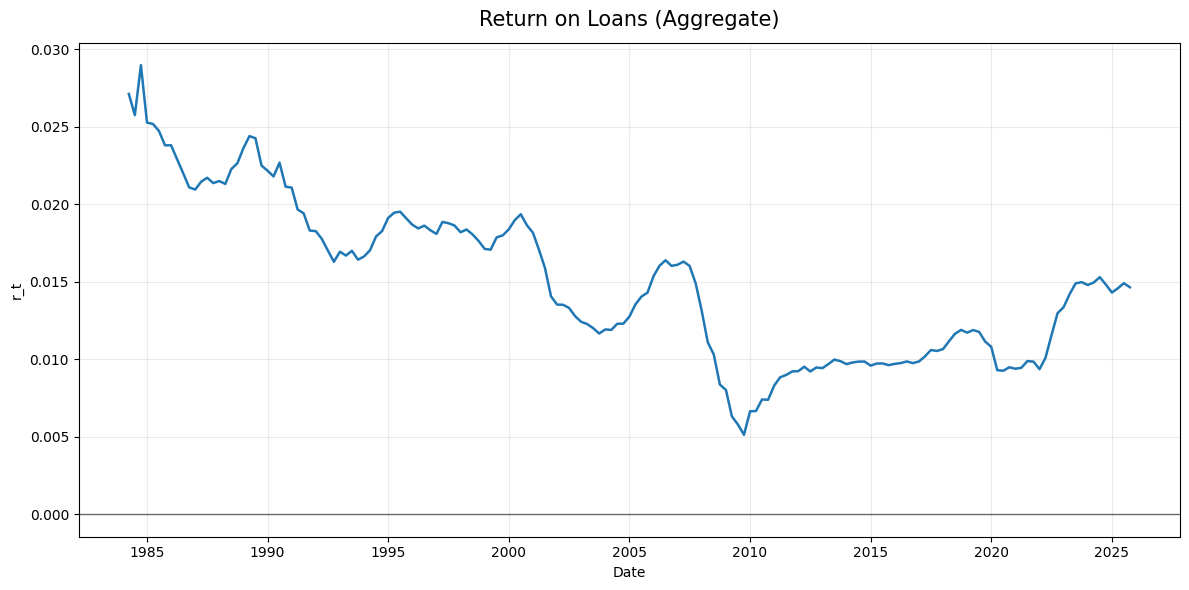

In [4]:

fig_rt, ax = plt.subplots(figsize=(12, 6))

ax.plot(fdic_data.index, fdic_data["r_t"], color="#1f77b4", linewidth=1.8)
ax.axhline(0, color="#333333", linewidth=1, alpha=0.7)

ax.set_title("Return on Loans (Aggregate)", fontsize=15, pad=12)
ax.set_xlabel("Date")
ax.set_ylabel("r_t")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))  
ax.xaxis.set_major_locator(mdates.YearLocator(5))         
ax.grid(True, alpha=0.25)

fig_rt.tight_layout()
plt.show()

In [6]:
# Define stress as quarters in top quartile of charge-off rate
threshold = fdic_data["net_chargeoffs"].quantile(0.75)
stress_mask = fdic_data["net_chargeoffs"] > threshold

mu_n    = fdic_data.loc[~stress_mask, "r_t"].mean()
sigma_n = fdic_data.loc[~stress_mask, "r_t"].std()
mu_s    = fdic_data.loc[stress_mask,  "r_t"].mean()
sigma_s = fdic_data.loc[stress_mask,  "r_t"].std()

print(f"mu_normal:    {mu_n:.6f}")
print(f"mu_stress:    {mu_s:.6f}")
print(f"sigma_normal: {sigma_n:.6f}")
print(f"sigma_stress: {sigma_s:.6f}")

mu_normal:    0.016391
mu_stress:    0.010866
sigma_normal: 0.004916
sigma_stress: 0.003074


In [10]:
from sklearn.mixture import GaussianMixture

CO = fdic_data["net_chargeoffs"].dropna().values.reshape(-1, 1)

gmm = GaussianMixture(n_components=2, n_init=20, random_state=42)
gmm.fit(CO)

# Stress state = high charge-off component
stress_idx = np.argmax(gmm.means_.flatten())
p_t = gmm.predict_proba(CO)[:, stress_idx]

In [8]:
# What is R* across alpha values?
alphas = np.linspace(0.01, 1.0, 10)
for a in alphas:
    R_star = 0.08 - 1/a
    Z_star_n = (R_star - mu_n) / sigma_n
    Z_star_s = (R_star - mu_s) / sigma_s
    print(f"alpha={a:.2f} | R*={R_star:.4f} | Z*_n={Z_star_n:.2f} | Z*_s={Z_star_s:.2f} | ES_n={ES(a,mu_n,sigma_n):.8f} | ES_s={ES(a,mu_s,sigma_s):.8f}")

alpha=0.01 | R*=-99.9200 | Z*_n=-20328.80 | Z*_s=-32508.41 | ES_n=0.00000000 | ES_s=0.00000000
alpha=0.12 | R*=-8.2533 | Z*_n=-1682.21 | Z*_s=-2688.42 | ES_n=0.00000000 | ES_s=0.00000000
alpha=0.23 | R*=-4.2678 | Z*_n=-871.48 | Z*_s=-1391.90 | ES_n=0.00000000 | ES_s=0.00000000
alpha=0.34 | R*=-2.8612 | Z*_n=-585.35 | Z*_s=-934.30 | ES_n=0.00000000 | ES_s=0.00000000
alpha=0.45 | R*=-2.1422 | Z*_n=-439.10 | Z*_s=-700.42 | ES_n=0.00000000 | ES_s=0.00000000
alpha=0.56 | R*=-1.7057 | Z*_n=-350.31 | Z*_s=-558.42 | ES_n=0.00000000 | ES_s=0.00000000
alpha=0.67 | R*=-1.4125 | Z*_n=-290.67 | Z*_s=-463.05 | ES_n=0.00000000 | ES_s=0.00000000
alpha=0.78 | R*=-1.2021 | Z*_n=-247.85 | Z*_s=-394.57 | ES_n=0.00000000 | ES_s=0.00000000
alpha=0.89 | R*=-1.0436 | Z*_n=-215.62 | Z*_s=-343.03 | ES_n=0.00000000 | ES_s=0.00000000
alpha=1.00 | R*=-0.9200 | Z*_n=-190.48 | Z*_s=-302.82 | ES_n=0.00000000 | ES_s=0.00000000


In [21]:
import numpy as np
import pandas as pd
from sklearn.mixture import GaussianMixture

df = fdic_data.copy()
df = df.dropna(subset=["r_t"]).copy()

# 1. Estimate slow-moving trend
# choose window depending on frequency:
# if quarterly data, 20 = 5-year rolling mean
# if monthly data, 60 = 5-year rolling mean
window = 20

df["trend"] = (
    df["r_t"]
    .rolling(window=window, center=True, min_periods=window // 2)
    .mean()
)

# Fill edge values
df["trend"] = df["trend"].bfill().ffill()

# 2. Detrend
df["eps_t"] = df["r_t"] - df["trend"]

# 3. Fit two-state Gaussian mixture to residuals
X = df[["eps_t"]].values

gmm = GaussianMixture(
    n_components=2,
    covariance_type="full",
    n_init=50,
    random_state=42
)

gmm.fit(X)

means = gmm.means_.flatten()
stds = np.sqrt(gmm.covariances_.flatten())
weights = gmm.weights_.flatten()

# 4. Label bad state as lower-mean component
bad_idx = np.argmin(means)
good_idx = 1 - bad_idx

mu_b = means[bad_idx]
sigma_b = stds[bad_idx]
p_bad = weights[bad_idx]

mu_g = means[good_idx]
sigma_g = stds[good_idx]
p_good = weights[good_idx]

print("Good state residual mean:", mu_g)
print("Good state residual std:", sigma_g)
print("Bad state residual mean:", mu_b)
print("Bad state residual std:", sigma_b)
print("Bad-state probability p:", p_bad)

# 5. Posterior probability of bad state at each date
posterior_probs = gmm.predict_proba(X)
df["p_bad_t"] = posterior_probs[:, bad_idx]
df["state"] = np.where(df["p_bad_t"] > 0.5, "bad", "good")

Good state residual mean: 0.00022335753213001858
Good state residual std: 0.0017453851114521343
Bad state residual mean: -0.00031952522272024245
Bad state residual std: 0.0017046278808579686
Bad-state probability p: 0.40630972078665467


In [32]:
import numpy as np
from hmmlearn import hmm

df = fdic_data.copy()
df = df.dropna(subset=["r_t"]).copy()

# 1. Rolling trend
window = 8
df["trend"] = df["r_t"].rolling(window=window, center=True, min_periods=window//2).mean()
df["trend"] = df["trend"].bfill().ffill()
df["eps_t"] = df["r_t"] - df["trend"]

# 2. Fit HMM on residuals (not standardised)
X = df["eps_t"].values.reshape(-1, 1)

model = hmm.GaussianHMM(
    n_components=2,
    covariance_type="diag",
    n_iter=2000,
    random_state=42,
    init_params=""        # manual initialisation
)

# Initialise based on what we see in the residual plot
# Normal: small positive deviation, tight variance
# Stress: negative deviation, wider variance
model.startprob_ = np.array([0.8, 0.2])
model.transmat_  = np.array([[0.97, 0.03],
                              [0.05, 0.95]])
model.means_     = np.array([[ 0.0015],   # normal
                              [-0.0030]])  # stress
model.covars_    = np.array([[0.000003],  # normal std ~ 0.0017
                              [0.000010]]) # stress std ~ 0.0032

model.fit(X)

# 3. Extract parameters — now in r_t units
means  = model.means_.flatten()
stds   = np.sqrt(model.covars_.flatten())

print("Transition matrix:\n", model.transmat_)
print("Regime means (residual units):", means)
print("Regime stds  (residual units):", stds)

stress_state = np.argmin(means)
normal_state = 1 - stress_state

print("Fraction stress:", (model.predict(X) == stress_state).mean())
print("Fraction normal:", (model.predict(X) == normal_state).mean())

# 4. Posterior stress probability
smoothed = model.predict_proba(X)
df["p_t"] = smoothed[:, stress_state]
df["state"] = np.where(df["p_t"] > 0.5, "stress", "normal")

# 5. Back-transform to r_t units for the objective
# trend is time-varying so we use its mean as a fixed anchor
trend_mean = df["trend"].mean()

mu_n = means[normal_state] + trend_mean
mu_s = means[stress_state] + trend_mean
sigma_n = stds[normal_state]
sigma_s = stds[stress_state]

print(f"\nObjective parameters (r_t units):")
print(f"mu_normal:    {mu_n:.6f}")
print(f"mu_stress:    {mu_s:.6f}")
print(f"sigma_normal: {sigma_n:.6f}")
print(f"sigma_stress: {sigma_s:.6f}")

Model is not converging.  Current: 655.5577715171514 is not greater than 828.8717616038248. Delta is -173.31399008667336


Transition matrix:
 [[9.99853038e-01 1.46961799e-04]
 [9.05557392e-01 9.44426080e-02]]
Regime means (residual units): [-3.31716277e-05 -2.88275214e-05]
Regime stds  (residual units): [0.00776099 0.60468854]
Fraction stress: 1.0
Fraction normal: 0.0

Objective parameters (r_t units):
mu_normal:    0.015006
mu_stress:    0.015002
sigma_normal: 0.604689
sigma_stress: 0.007761


In [35]:
from statsmodels.tsa.filters.hp_filter import hpfilter

cycle, trend = hpfilter(df["r_t"].dropna(), lamb=1600)  # standard for quarterly
df["trend"] = trend.values
df["eps_t"] = cycle.values  # stationary residuals with more variation preserved
df["eps_t"].describe()

count    1.670000e+02
mean    -1.319844e-16
std      1.453538e-03
min     -4.118317e-03
25%     -1.147875e-03
50%      1.972725e-05
75%      8.373414e-04
max      3.848854e-03
Name: eps_t, dtype: float64

In [36]:
X = df["eps_t"].values.reshape(-1, 1)

model = hmm.GaussianHMM(
    n_components=2,
    covariance_type="diag",
    n_iter=2000,
    random_state=42,
    init_params=""
)

model.startprob_ = np.array([0.8, 0.2])
model.transmat_  = np.array([[0.97, 0.03],
                              [0.05, 0.95]])

# Based on the actual percentiles above:
# normal ~ positive deviation, stress ~ negative deviation
model.means_  = np.array([[ 0.0008],   # roughly 75th pct
                           [-0.0015]])  # roughly 20th pct

# Variance: (std/2)^2 for normal, (std)^2 for stress
model.covars_ = np.array([[5e-7],    # std ~ 0.0007, tight
                           [3e-6]])  # std ~ 0.0017, wider

model.fit(X)

means = model.means_.flatten()
stds  = np.sqrt(model.covars_.flatten())

print("Regime means:", means)
print("Regime stds:", stds)
print("Transition matrix:\n", model.transmat_)

states = model.predict(X)
print("Fraction stress:", (states == np.argmin(means)).mean())
print("Fraction normal:", (states == np.argmax(means)).mean())

Model is not converging.  Current: 602.8489311636224 is not greater than 866.245591345292. Delta is -263.39666018166963


Regime means: [ 1.19226194e-05 -8.47089189e-05]
Regime stds: [0.00839102 0.02207735]
Transition matrix:
 [[0.9765957  0.0234043 ]
 [0.15779511 0.84220489]]
Fraction stress: 0.0
Fraction normal: 1.0


EBP descriptive stats:
count    639.000000
mean       0.063562
std        0.533350
min       -1.068978
25%       -0.253053
50%       -0.044934
75%        0.205086
max        3.409312
Name: EBP, dtype: float64

HMM Regime means: [-0.14696942  0.76947207]
HMM Regime stds:  [0.23552919 0.63524048]
Transition matrix:
 [[0.98213878 0.01786122]
 [0.05975249 0.94024751]]

Fraction stress: 0.224
Fraction normal: 0.776

Merged observations: 0
Stress periods: 0
Normal periods: 0

=== Objective Parameters ===
mu_normal:    nan
sigma_normal: nan
mu_stress:    nan
sigma_stress: nan
p_bar (unconditional): nan


ValueError: zero-size array to reduction operation minimum which has no identity

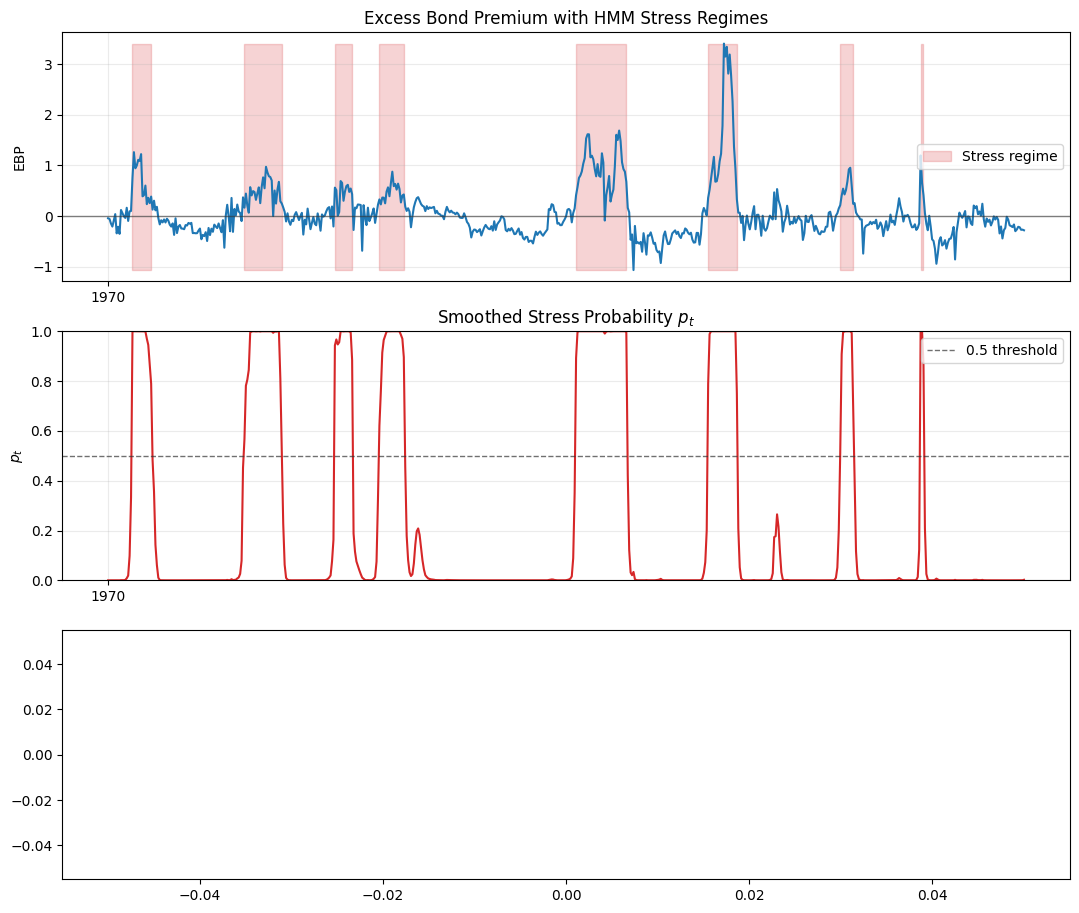

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from hmmlearn import hmm

# ── 0. Load data ────────────────────────────────────────────────────────────
# Assumes you have:
#   ebp_data : DataFrame with DatetimeIndex and column "EBP"
#   fdic_data: DataFrame with DatetimeIndex and column "r_t"

ebp_data = pd.read_csv('raw/ebp.csv')


# ── 1. Fit HMM on EBP ───────────────────────────────────────────────────────
ebp_clean = ebp_data.dropna(subset=["EBP"]).copy()
X = ebp_clean["EBP"].values.reshape(-1, 1)

print("EBP descriptive stats:")
print(ebp_clean["EBP"].describe())

model = hmm.GaussianHMM(
    n_components=2,
    covariance_type="diag",
    n_iter=2000,
    random_state=42,
    init_params=""
)

model.startprob_ = np.array([0.8, 0.2])
model.transmat_  = np.array([[0.97, 0.03],
                              [0.05, 0.95]])
model.means_     = np.array([[-0.15],   # normal: low EBP
                              [ 0.40]])  # stress: high EBP
model.covars_    = np.array([[0.01],
                             [0.04]])

model.fit(X)

# Check convergence
means_hmm = model.means_.flatten()
stds_hmm  = np.sqrt(model.covars_.flatten())
print("\nHMM Regime means:", means_hmm)
print("HMM Regime stds: ", stds_hmm)
print("Transition matrix:\n", model.transmat_)

# High EBP = stress
stress_state = np.argmax(model.means_.flatten())
normal_state = 1 - stress_state

states        = model.predict(X)
smoothed_probs = model.predict_proba(X)

print(f"\nFraction stress: {(states == stress_state).mean():.3f}")
print(f"Fraction normal: {(states == normal_state).mean():.3f}")

ebp_clean["p_t"]    = smoothed_probs[:, stress_state]
ebp_clean["state"]  = np.where(ebp_clean["p_t"] > 0.5, "stress", "normal")

# ── 2. Merge EBP regimes onto r_t ───────────────────────────────────────────
fdic_clean = fdic_data.dropna(subset=["r_t"]).copy()

merged = fdic_clean.merge(
    ebp_clean[["p_t", "state"]],
    left_index=True,
    right_index=True,
    how="inner"
)

print(f"\nMerged observations: {len(merged)}")
print(f"Stress periods: {(merged['state'] == 'stress').sum()}")
print(f"Normal periods: {(merged['state'] == 'normal').sum()}")

# ── 3. Estimate regime parameters from r_t ──────────────────────────────────
normal_returns = merged.loc[merged["state"] == "normal", "r_t"]
stress_returns = merged.loc[merged["state"] == "stress", "r_t"]

mu_n    = normal_returns.mean()
sigma_n = normal_returns.std()
mu_s    = stress_returns.mean()
sigma_s = stress_returns.std()

p_bar = (merged["state"] == "stress").mean()   # unconditional stress probability

print("\n=== Objective Parameters ===")
print(f"mu_normal:    {mu_n:.6f}")
print(f"sigma_normal: {sigma_n:.6f}")
print(f"mu_stress:    {mu_s:.6f}")
print(f"sigma_stress: {sigma_s:.6f}")
print(f"p_bar (unconditional): {p_bar:.6f}")

# ── 4. Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=False)

# Panel 1: EBP with regime shading
ax = axes[0]
ax.plot(ebp_clean.index, ebp_clean["EBP"], color="#1f77b4", linewidth=1.5)
ax.fill_between(ebp_clean.index,
                ebp_clean["EBP"].min(), ebp_clean["EBP"].max(),
                where=(ebp_clean["state"] == "stress"),
                color="#d62728", alpha=0.2, label="Stress regime")
ax.axhline(0, color="#333333", linewidth=1, alpha=0.6)
ax.set_title("Excess Bond Premium with HMM Stress Regimes")
ax.set_ylabel("EBP")
ax.legend()
ax.grid(True, alpha=0.25)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(5))

# Panel 2: p_t
ax = axes[1]
ax.plot(ebp_clean.index, ebp_clean["p_t"], color="#d62728", linewidth=1.5)
ax.axhline(0.5, color="#333333", linewidth=1, linestyle="--", alpha=0.7, label="0.5 threshold")
ax.set_title("Smoothed Stress Probability $p_t$")
ax.set_ylabel("$p_t$")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, alpha=0.25)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(5))

# Panel 3: r_t with regime shading (on merged sample)
ax = axes[2]

# Convert to numpy arrays to avoid index alignment issues
dates    = merged.index.to_numpy()
r_vals   = merged["r_t"].to_numpy()
is_stress = (merged["state"] == "stress").to_numpy()

ax.plot(dates, r_vals, color="#1f77b4", linewidth=1.5)
ax.fill_between(dates, r_vals.min(), r_vals.max(),
                where=is_stress,
                color="#d62728", alpha=0.2, label="Stress regime")

ax.axhline(mu_n, color="#2ca02c", linewidth=1.5, linestyle="--",
           label=f"$\\mu_n$ = {mu_n:.4f}")
ax.axhline(mu_s, color="#d62728", linewidth=1.5, linestyle="--",
           label=f"$\\mu_s$ = {mu_s:.4f}")

ax.set_title("Loan Returns $r_t$ by Regime")
ax.set_ylabel("$r_t$")
ax.legend()
ax.grid(True, alpha=0.25)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(5))

fig.tight_layout()
plt.show()

# ── 5. Summary table ─────────────────────────────────────────────────────────
print("\n=== Regime Summary ===")
print(merged.groupby("state")["r_t"].describe().round(6))

EBP index dtype: datetime64[us]
EBP first 3: [Timestamp('1973-01-01 00:00:00'), Timestamp('1973-02-01 00:00:00'), Timestamp('1973-03-01 00:00:00')]
FDIC first 3: [Timestamp('1984-04-01 00:00:00'), Timestamp('1984-07-01 00:00:00'), Timestamp('1984-10-01 00:00:00')]
EBP descriptive stats:
count    639.000000
mean       0.063562
std        0.533350
min       -1.068978
25%       -0.253053
50%       -0.044934
75%        0.205086
max        3.409312
Name: EBP, dtype: float64

HMM Regime means: [-0.14696942  0.76947207]
HMM Regime stds:  [0.23552919 0.63524048]
Transition matrix:
 [[0.98213878 0.01786122]
 [0.05975249 0.94024751]]

Fraction stress: 0.224
Fraction normal: 0.776

Merged observations: 167
Stress periods: 34
Normal periods: 133
Date range: 1984-04-01 00:00:00 to 2025-10-01 00:00:00

=== Objective Parameters ===
mu_normal:    0.014888
sigma_normal: 0.004941
mu_stress:    0.015447
sigma_stress: 0.005806
p_bar (unconditional stress probability): 0.203593


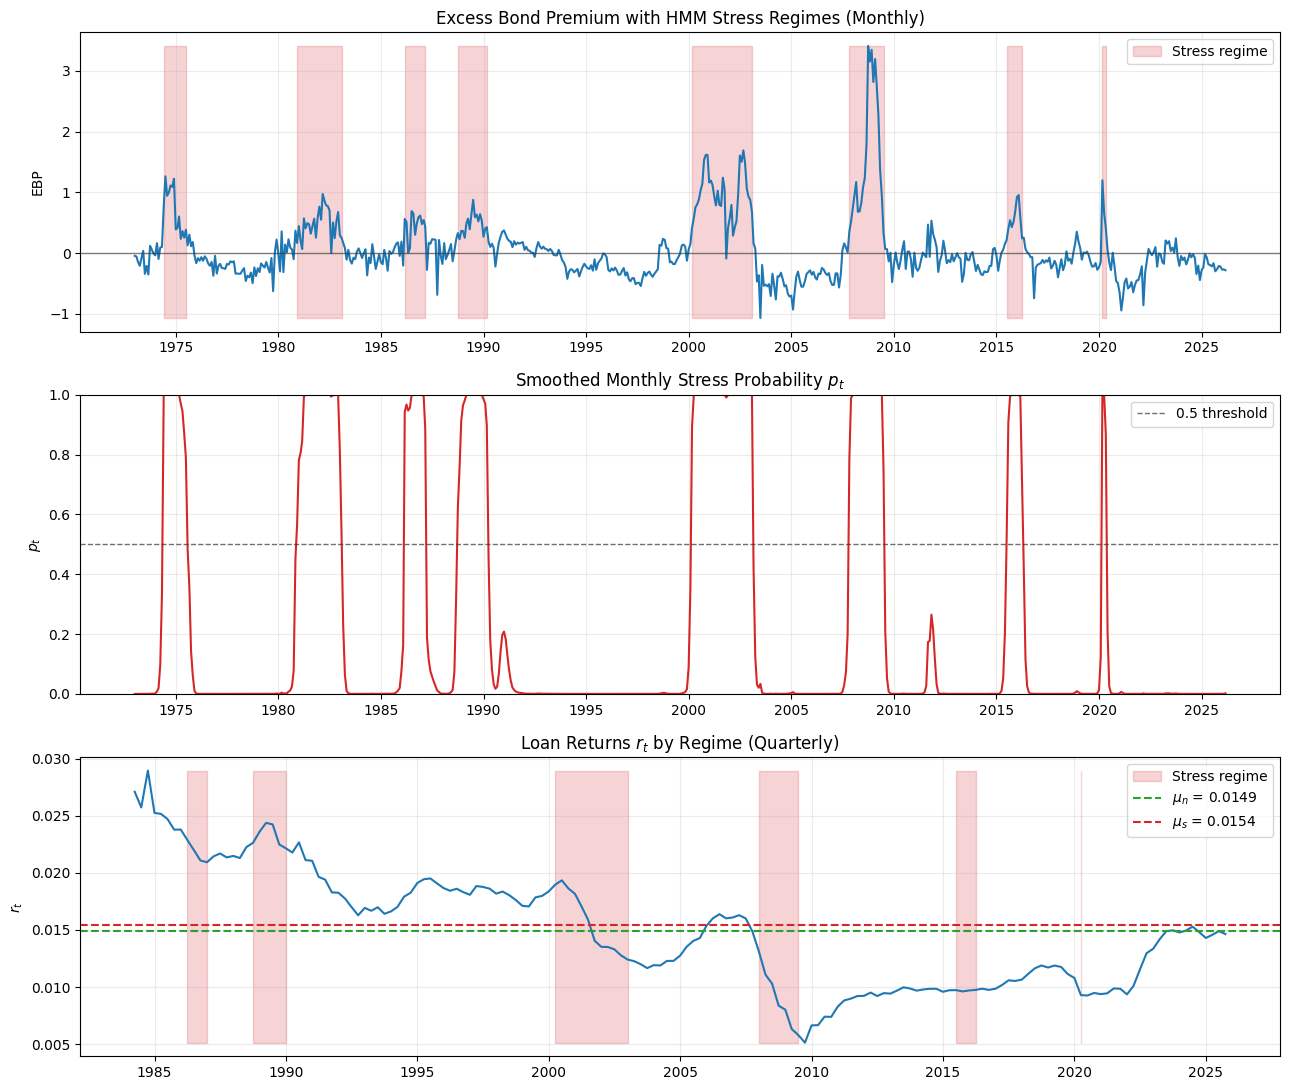


=== Regime Summary (r_t) ===
        count      mean       std       min       25%       50%       75%  \
state                                                                       
normal  133.0  0.014888  0.004941  0.005124  0.010086  0.014885  0.018297   
stress   34.0  0.015447  0.005806  0.005792  0.009887  0.013790  0.021049   

             max  
state             
normal  0.028966  
stress  0.024388  

=== Monthly p_t series (first 10) ===
                 EBP           p_t   state
DATE                                      
1973-01-01 -0.044934  1.790142e-23  normal
1973-02-01 -0.056665  2.163335e-04  normal
1973-03-01 -0.147828  1.907429e-04  normal
1973-04-01 -0.208642  1.769429e-04  normal
1973-05-01 -0.083211  2.491291e-04  normal
1973-06-01  0.036957  3.752128e-04  normal
1973-07-01 -0.342664  1.823136e-04  normal
1973-08-01 -0.212017  1.721057e-04  normal
1973-09-01 -0.352632  2.210372e-04  normal
1973-10-01  0.119423  7.200790e-04  normal


In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from hmmlearn import hmm

# ── 0. Fix EBP index — DATE is a column, not the index ──────────────────────
ebp_clean = ebp_data.copy()

# If DATE is a column
if "DATE" in ebp_clean.columns:
    ebp_clean = ebp_clean.set_index("DATE")

# Convert to datetime properly
ebp_clean.index = pd.to_datetime(ebp_clean.index)
fdic_clean = fdic_data.dropna(subset=["r_t"]).copy()
fdic_clean.index = pd.to_datetime(fdic_clean.index)

# Verify
print("EBP index dtype:", ebp_clean.index.dtype)
print("EBP first 3:", ebp_clean.index[:3].tolist())
print("FDIC first 3:", fdic_clean.index[:3].tolist())

# ── 1. Fit HMM on monthly EBP ────────────────────────────────────────────────
X = ebp_clean["EBP"].values.reshape(-1, 1)

print("EBP descriptive stats:")
print(ebp_clean["EBP"].describe())

model = hmm.GaussianHMM(
    n_components=2,
    covariance_type="diag",
    n_iter=2000,
    random_state=42,
    init_params=""
)

model.startprob_ = np.array([0.8, 0.2])
model.transmat_  = np.array([[0.97, 0.03],
                              [0.05, 0.95]])
model.means_     = np.array([[-0.15],
                              [ 0.40]])
model.covars_    = np.array([[0.01],
                             [0.04]])

model.fit(X)

means_hmm = model.means_.flatten()
stds_hmm  = np.sqrt(model.covars_.flatten())

print("\nHMM Regime means:", means_hmm)
print("HMM Regime stds: ", stds_hmm)
print("Transition matrix:\n", model.transmat_)

# High EBP = stress
stress_state   = np.argmax(model.means_.flatten())
normal_state   = 1 - stress_state
states         = model.predict(X)
smoothed_probs = model.predict_proba(X)

print(f"\nFraction stress: {(states == stress_state).mean():.3f}")
print(f"Fraction normal: {(states == normal_state).mean():.3f}")

# Assign monthly p_t and state to ebp_clean
ebp_clean["p_t"]   = smoothed_probs[:, stress_state]
ebp_clean["state"] = np.where(ebp_clean["p_t"] > 0.5, "stress", "normal")

# ── 2. Merge monthly p_t onto quarterly FDIC using nearest date ──────────────
# Strategy: for each quarterly FDIC date, find the closest monthly EBP date
# pd.merge_asof does this efficiently on sorted indices

ebp_for_merge  = ebp_clean[["p_t", "state", "EBP"]].reset_index().rename(columns={"index": "DATE"})
fdic_for_merge = fdic_clean.reset_index().rename(columns={"index": "DATE"})

# Ensure datetime
ebp_for_merge["DATE"]  = pd.to_datetime(ebp_for_merge["DATE"])
fdic_for_merge["DATE"] = pd.to_datetime(fdic_for_merge["DATE"])

ebp_for_merge  = ebp_for_merge.sort_values("DATE")
fdic_for_merge = fdic_for_merge.sort_values("DATE")

merged_reset = pd.merge_asof(
    fdic_for_merge,
    ebp_for_merge,
    on="DATE",
    direction="nearest"
)

merged = merged_reset.set_index("DATE")

print(f"\nMerged observations: {len(merged)}")
print(f"Stress periods: {(merged['state'] == 'stress').sum()}")
print(f"Normal periods: {(merged['state'] == 'normal').sum()}")
print(f"Date range: {merged.index.min()} to {merged.index.max()}")

# ── 3. Estimate regime parameters from r_t ───────────────────────────────────
normal_returns = merged.loc[merged["state"] == "normal", "r_t"]
stress_returns = merged.loc[merged["state"] == "stress", "r_t"]

mu_n    = normal_returns.mean()
sigma_n = normal_returns.std()
mu_s    = stress_returns.mean()
sigma_s = stress_returns.std()
p_bar   = (merged["state"] == "stress").mean()

print("\n=== Objective Parameters ===")
print(f"mu_normal:    {mu_n:.6f}")
print(f"sigma_normal: {sigma_n:.6f}")
print(f"mu_stress:    {mu_s:.6f}")
print(f"sigma_stress: {sigma_s:.6f}")
print(f"p_bar (unconditional stress probability): {p_bar:.6f}")

# ── 4. Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(13, 11))

# Panel 1: EBP with regime shading (monthly)
ax = axes[0]
dates_ebp     = ebp_clean.index.to_numpy()
ebp_vals      = ebp_clean["EBP"].to_numpy()
is_stress_ebp = (ebp_clean["state"] == "stress").to_numpy()

ax.plot(dates_ebp, ebp_vals, color="#1f77b4", linewidth=1.5)
ax.fill_between(dates_ebp,
                ebp_vals.min(), ebp_vals.max(),
                where=is_stress_ebp,
                color="#d62728", alpha=0.2, label="Stress regime")
ax.axhline(0, color="#333333", linewidth=1, alpha=0.6)
ax.set_title("Excess Bond Premium with HMM Stress Regimes (Monthly)")
ax.set_ylabel("EBP")
ax.legend()
ax.grid(True, alpha=0.25)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(5))

# Panel 2: Monthly p_t
ax = axes[1]
dates_pt = ebp_clean.index.to_numpy()
pt_vals  = ebp_clean["p_t"].to_numpy()

ax.plot(dates_pt, pt_vals, color="#d62728", linewidth=1.5)
ax.axhline(0.5, color="#333333", linewidth=1,
           linestyle="--", alpha=0.7, label="0.5 threshold")
ax.set_title("Smoothed Monthly Stress Probability $p_t$")
ax.set_ylabel("$p_t$")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, alpha=0.25)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(5))

# Panel 3: Quarterly r_t with regime shading
ax = axes[2]
dates_r   = merged.index.to_numpy()
r_vals    = merged["r_t"].to_numpy()
is_stress = (merged["state"] == "stress").to_numpy()

ax.plot(dates_r, r_vals, color="#1f77b4", linewidth=1.5)
ax.fill_between(dates_r,
                float(np.nanmin(r_vals)), float(np.nanmax(r_vals)),
                where=is_stress,
                color="#d62728", alpha=0.2, label="Stress regime")
ax.axhline(mu_n, color="#2ca02c", linewidth=1.5, linestyle="--",
           label=f"$\\mu_n$ = {mu_n:.4f}")
ax.axhline(mu_s, color="#d62728", linewidth=1.5, linestyle="--",
           label=f"$\\mu_s$ = {mu_s:.4f}")
ax.set_title("Loan Returns $r_t$ by Regime (Quarterly)")
ax.set_ylabel("$r_t$")
ax.legend()
ax.grid(True, alpha=0.25)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(5))

fig.tight_layout()
plt.show()

# ── 5. Summary table ──────────────────────────────────────────────────────────
print("\n=== Regime Summary (r_t) ===")
print(merged.groupby("state")["r_t"].describe().round(6))

# ── 6. Save p_t series for modelling ─────────────────────────────────────────
# This is your monthly prediction target for the DFL model
p_t_series = ebp_clean[["EBP", "p_t", "state"]].copy()
print("\n=== Monthly p_t series (first 10) ===")
print(p_t_series.head(10))

In [46]:
# Option 1: restrict regime parameter estimation to the FDIC sample only
# (already done via the inner merge — but check the overlap)
print("Merged date range:", merged.index.min(), "to", merged.index.max())
print("\nStress periods in merged sample:")
print(merged[merged["state"] == "stress"].index.tolist())

# Option 2: if 1984-1990 stress periods are causing the issue,
# check what r_t looks like during those quarters
print("\nr_t during stress periods:")
print(merged[merged["state"] == "stress"]["r_t"].describe())

print("\nr_t during normal periods:")
print(merged[merged["state"] == "normal"]["r_t"].describe())

Merged date range: 1984-04-01 00:00:00 to 2025-10-01 00:00:00

Stress periods in merged sample:
[Timestamp('1986-04-01 00:00:00'), Timestamp('1986-07-01 00:00:00'), Timestamp('1986-10-01 00:00:00'), Timestamp('1987-01-01 00:00:00'), Timestamp('1988-10-01 00:00:00'), Timestamp('1989-01-01 00:00:00'), Timestamp('1989-04-01 00:00:00'), Timestamp('1989-07-01 00:00:00'), Timestamp('1989-10-01 00:00:00'), Timestamp('1990-01-01 00:00:00'), Timestamp('2000-04-01 00:00:00'), Timestamp('2000-07-01 00:00:00'), Timestamp('2000-10-01 00:00:00'), Timestamp('2001-01-01 00:00:00'), Timestamp('2001-04-01 00:00:00'), Timestamp('2001-07-01 00:00:00'), Timestamp('2001-10-01 00:00:00'), Timestamp('2002-01-01 00:00:00'), Timestamp('2002-04-01 00:00:00'), Timestamp('2002-07-01 00:00:00'), Timestamp('2002-10-01 00:00:00'), Timestamp('2003-01-01 00:00:00'), Timestamp('2008-01-01 00:00:00'), Timestamp('2008-04-01 00:00:00'), Timestamp('2008-07-01 00:00:00'), Timestamp('2008-10-01 00:00:00'), Timestamp('2009-01-

In [43]:
# ── Diagnose ─────────────────────────────────────────────────────────────────
print("=== RAW INDICES BEFORE ANY CONVERSION ===")
print("EBP raw index dtype:", ebp_data.index.dtype)
print("EBP raw first 3:", ebp_data.index[:3].tolist())
print("FDIC raw index dtype:", fdic_data.index.dtype)
print("FDIC raw first 3:", fdic_data.index[:3].tolist())

print("\n=== AFTER CONVERSION ===")
print("EBP converted first 3:", ebp_clean.index[:3].tolist())
print("FDIC converted first 3:", fdic_clean.index[:3].tolist())

print("\n=== MERGE INPUTS ===")
print("ebp_for_merge DATE first 3:", ebp_for_merge["DATE"][:3].tolist())
print("fdic_for_merge DATE first 3:", fdic_for_merge["DATE"][:3].tolist())

print("\n=== STATE DISTRIBUTION ===")
print(ebp_clean["state"].value_counts())
print("\nMerged state distribution:")
print(merged["state"].value_counts())

=== RAW INDICES BEFORE ANY CONVERSION ===
EBP raw index dtype: int64
EBP raw first 3: [0, 1, 2]
FDIC raw index dtype: datetime64[us]
FDIC raw first 3: [Timestamp('1984-01-01 00:00:00'), Timestamp('1984-04-01 00:00:00'), Timestamp('1984-07-01 00:00:00')]

=== AFTER CONVERSION ===
EBP converted first 3: [Timestamp('1970-01-01 00:00:00'), Timestamp('1970-01-01 00:00:00'), Timestamp('1970-01-01 00:00:00')]
FDIC converted first 3: [Timestamp('1984-04-01 00:00:00'), Timestamp('1984-07-01 00:00:00'), Timestamp('1984-10-01 00:00:00')]

=== MERGE INPUTS ===
ebp_for_merge DATE first 3: [Timestamp('1970-01-01 00:00:00'), Timestamp('1970-01-01 00:00:00'), Timestamp('1970-01-01 00:00:00')]
fdic_for_merge DATE first 3: [Timestamp('1984-04-01 00:00:00'), Timestamp('1984-07-01 00:00:00'), Timestamp('1984-10-01 00:00:00')]

=== STATE DISTRIBUTION ===
state
normal    497
stress    142
Name: count, dtype: int64

Merged state distribution:
state
normal    167
Name: count, dtype: int64


import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(df.index, df["r_t"], label="Raw loan return")
plt.plot(df.index, df["trend"], label="Trend")
plt.legend()
plt.title("Loan return and estimated trend")
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(df.index, df["eps_t"], label="Detrended loan return")
plt.scatter(
    df.index[df["state"] == "bad"],
    df.loc[df["state"] == "bad", "eps_t"],
    label="Estimated bad state",
    zorder=3
)
plt.axhline(0, linewidth=1)
plt.legend()
plt.title("Detrended loan return with estimated bad-state periods")
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(df.index, df["p_bad_t"])
plt.title("Posterior probability of bad state")
plt.ylabel("P(bad state)")
plt.show()

In [23]:
window = 20  # quarterly: 5 years

df["trend"] = (
    df["r_t"]
    .rolling(window=window, center=True, min_periods=window // 2)
    .mean()
    .bfill()
    .ffill()
)

df["resid"] = df["r_t"] - df["trend"]

df["rolling_sigma"] = (
    df["resid"]
    .rolling(window=window, center=True, min_periods=window // 2)
    .std()
    .bfill()
    .ffill()
)

df["z_return"] = df["resid"] / df["rolling_sigma"]

X = df[["z_return"]].dropna().values

gmm = GaussianMixture(
    n_components=2,
    covariance_type="full",
    n_init=100,
    random_state=42
)

gmm.fit(X)

means = gmm.means_.flatten()
stds = np.sqrt(gmm.covariances_.flatten())
weights = gmm.weights_.flatten()

bad_idx = np.argmin(means)
good_idx = 1 - bad_idx

mu_b = means[bad_idx]
sigma_b = stds[bad_idx]
p_bad = weights[bad_idx]

mu_g = means[good_idx]
sigma_g = stds[good_idx]
p_good = weights[good_idx]

print("mu_g:", mu_g)
print("sigma_g:", sigma_g)
print("mu_b:", mu_b)
print("sigma_b:", sigma_b)
print("p_bad:", p_bad)

mu_g: 0.6409558712895318
sigma_g: 0.623403525935676
mu_b: -0.952173742676141
sigma_b: 0.4098591764603306
p_bad: 0.39850982083142283


In [24]:
tau = 0.15

threshold = df["resid"].quantile(tau)
df["bad_quantile"] = df["resid"] <= threshold

bad = df.loc[df["bad_quantile"], "resid"]
good = df.loc[~df["bad_quantile"], "resid"]

mu_b = bad.mean()
sigma_b = bad.std()
mu_g = good.mean()
sigma_g = good.std()
p_bad = df["bad_quantile"].mean()

print("Threshold:", threshold)
print("mu_g:", mu_g)
print("sigma_g:", sigma_g)
print("mu_b:", mu_b)
print("sigma_b:", sigma_b)
print("p_bad:", p_bad)

Threshold: -0.0014256778946046737
mu_g: 0.0003715008868709983
sigma_g: 0.0011902942295892826
mu_b: -0.0020915613736266505
sigma_b: 0.000799583730239612
p_bad: 0.1497005988023952


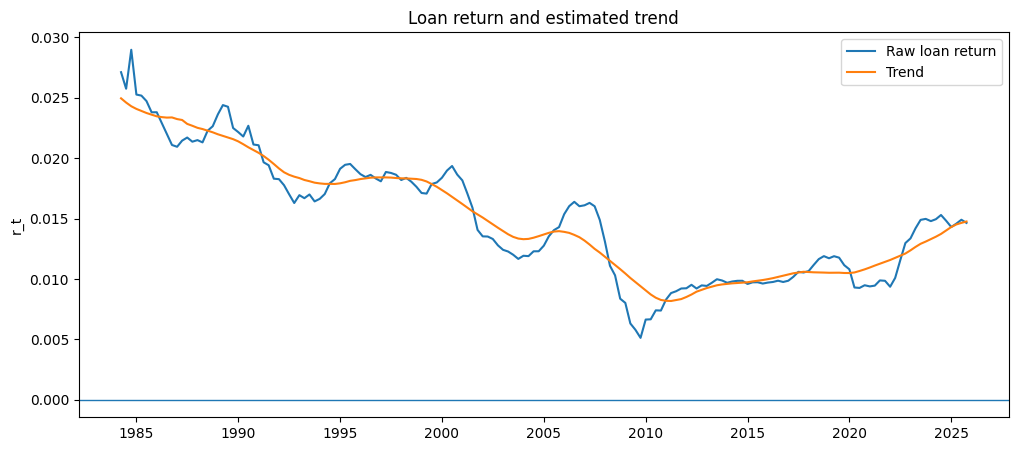

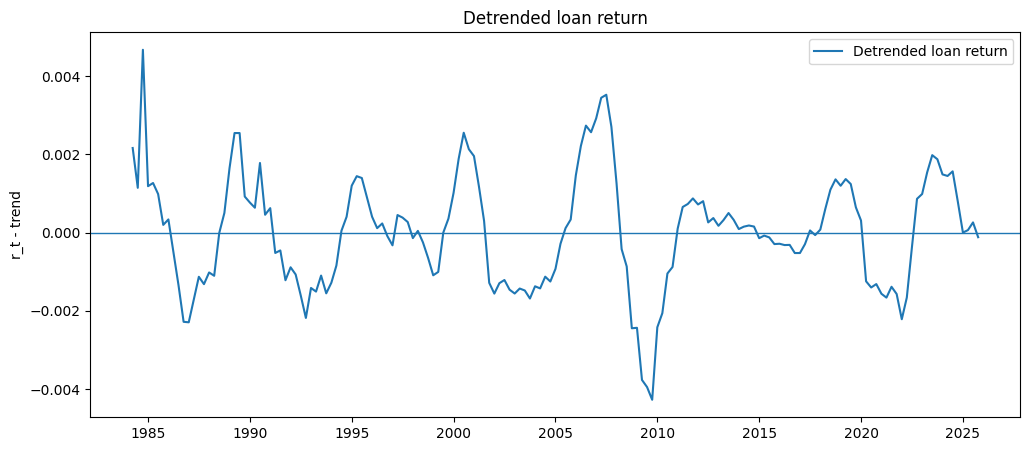

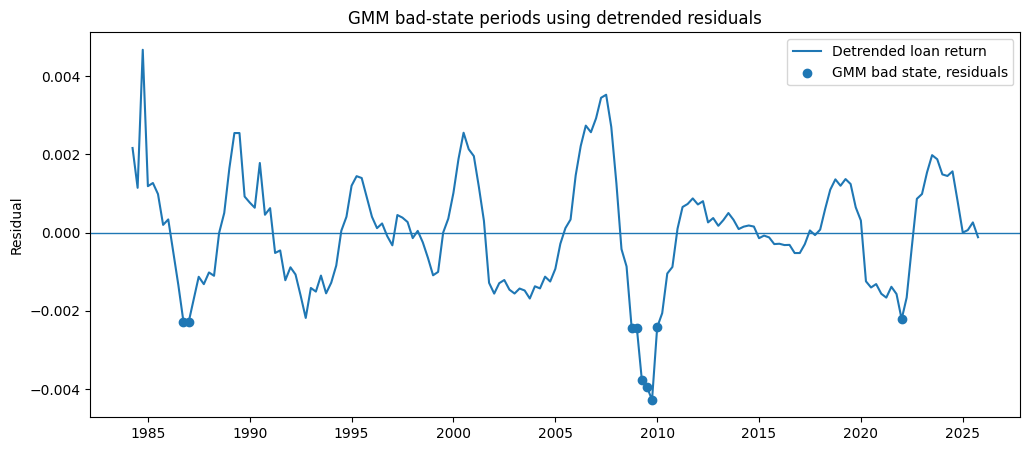

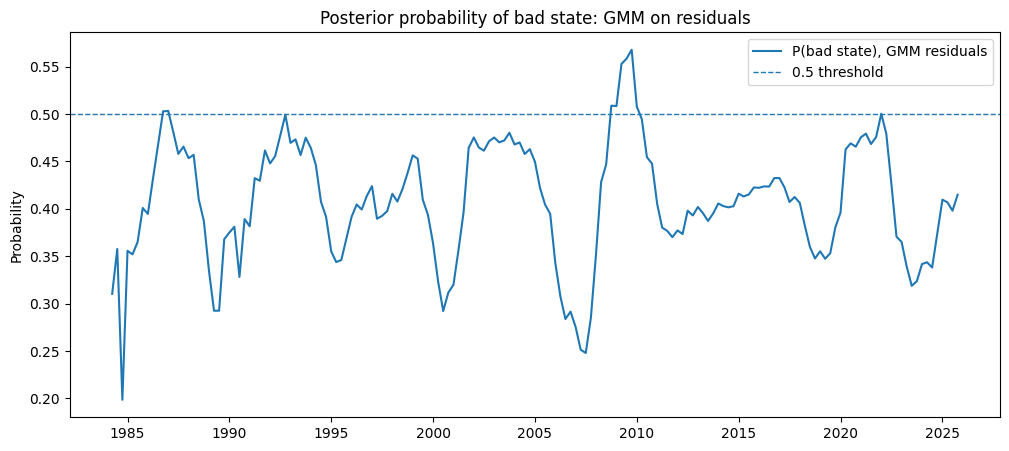

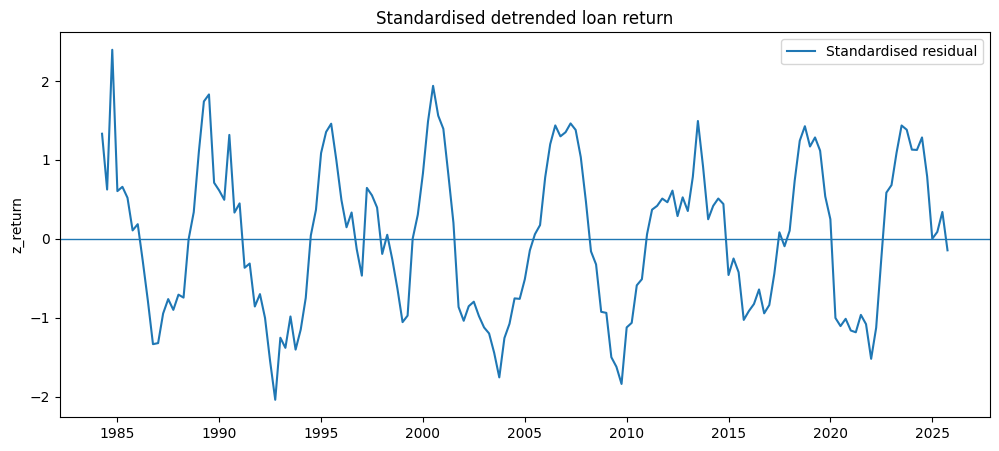

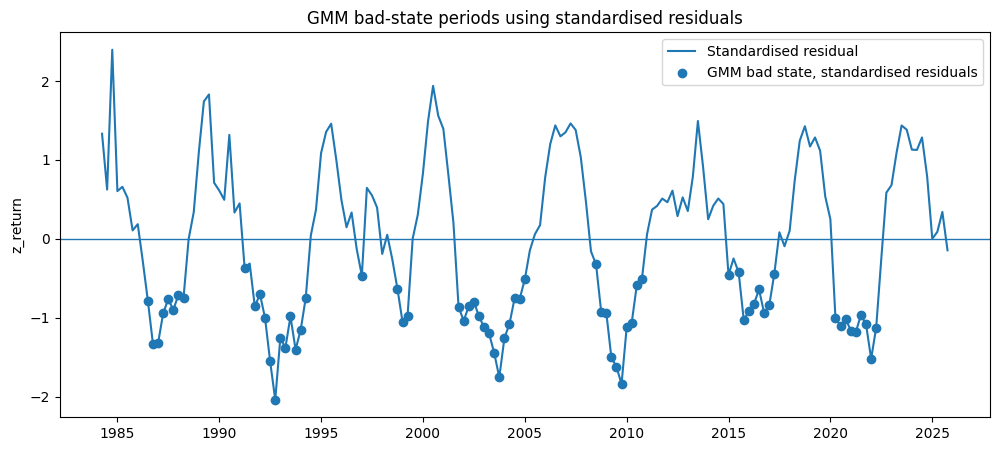

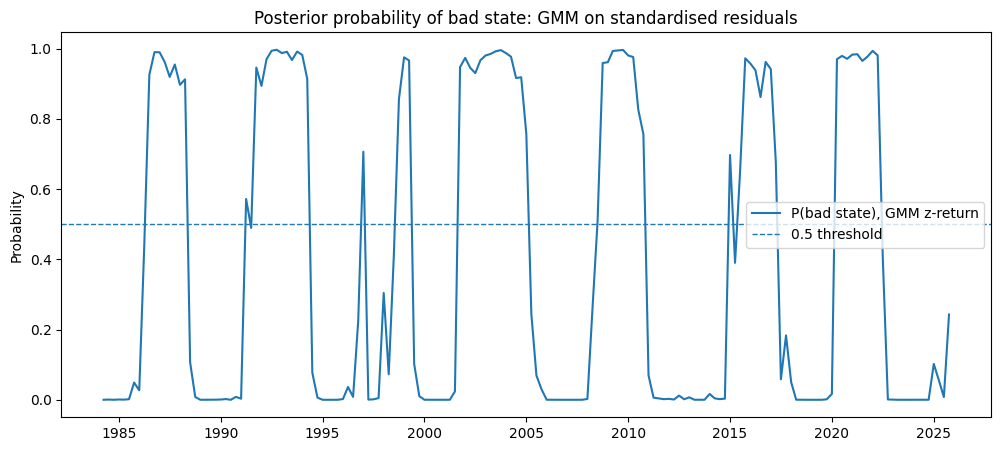

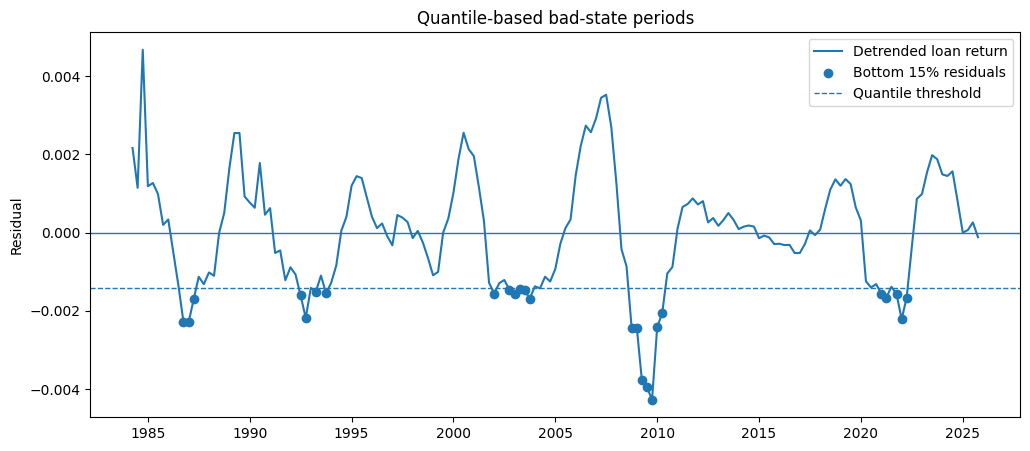

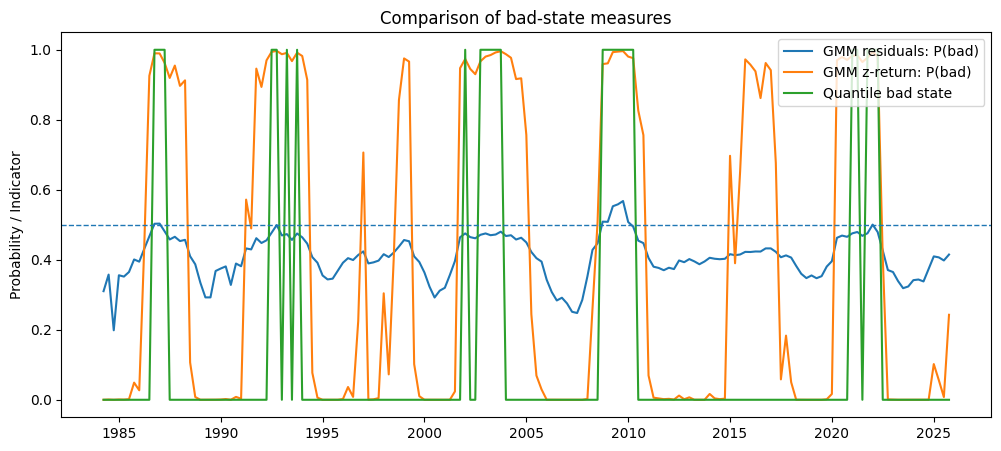

In [30]:
# -----------------------------
# Plot 1: Raw loan return and trend
# -----------------------------

plt.figure(figsize=(12, 5))
plt.plot(df.index, df["r_t"], label="Raw loan return")
plt.plot(df.index, df["trend"], label="Trend")
plt.axhline(0, linewidth=1)
plt.title("Loan return and estimated trend")
plt.ylabel("r_t")
plt.legend()
plt.show()


# -----------------------------
# Plot 2: Residuals after detrending
# -----------------------------

plt.figure(figsize=(12, 5))
plt.plot(df.index, df["resid"], label="Detrended loan return")
plt.axhline(0, linewidth=1)
plt.title("Detrended loan return")
plt.ylabel("r_t - trend")
plt.legend()
plt.show()


# -----------------------------
# Plot 3: GMM on residuals, hard bad-state labels
# -----------------------------

plt.figure(figsize=(12, 5))
plt.plot(df.index, df["resid"], label="Detrended loan return")
plt.scatter(
    df.index[df["bad_gmm_resid"]],
    df.loc[df["bad_gmm_resid"], "resid"],
    label="GMM bad state, residuals",
    zorder=3
)
plt.axhline(0, linewidth=1)
plt.title("GMM bad-state periods using detrended residuals")
plt.ylabel("Residual")
plt.legend()
plt.show()


# -----------------------------
# Plot 4: GMM posterior probability on residuals
# -----------------------------

plt.figure(figsize=(12, 5))
plt.plot(df.index, df["p_bad_gmm_resid"], label="P(bad state), GMM residuals")
plt.axhline(0.5, linestyle="--", linewidth=1, label="0.5 threshold")
plt.title("Posterior probability of bad state: GMM on residuals")
plt.ylabel("Probability")
plt.legend()
plt.show()


# -----------------------------
# Plot 5: Standardised residuals
# -----------------------------

plt.figure(figsize=(12, 5))
plt.plot(df.index, df["z_return"], label="Standardised residual")
plt.axhline(0, linewidth=1)
plt.title("Standardised detrended loan return")
plt.ylabel("z_return")
plt.legend()
plt.show()


# -----------------------------
# Plot 6: GMM on standardised residuals, hard bad-state labels
# -----------------------------

plt.figure(figsize=(12, 5))
plt.plot(df.index, df["z_return"], label="Standardised residual")
plt.scatter(
    df.index[df["bad_gmm_z"]],
    df.loc[df["bad_gmm_z"], "z_return"],
    label="GMM bad state, standardised residuals",
    zorder=3
)
plt.axhline(0, linewidth=1)
plt.title("GMM bad-state periods using standardised residuals")
plt.ylabel("z_return")
plt.legend()
plt.show()


# -----------------------------
# Plot 7: GMM posterior probability on standardised residuals
# -----------------------------

plt.figure(figsize=(12, 5))
plt.plot(df.index, df["p_bad_gmm_z"], label="P(bad state), GMM z-return")
plt.axhline(0.5, linestyle="--", linewidth=1, label="0.5 threshold")
plt.title("Posterior probability of bad state: GMM on standardised residuals")
plt.ylabel("Probability")
plt.legend()
plt.show()


# -----------------------------
# Plot 8: Quantile bad-state rule
# -----------------------------

plt.figure(figsize=(12, 5))
plt.plot(df.index, df["resid"], label="Detrended loan return")
plt.scatter(
    df.index[df["bad_quantile"]],
    df.loc[df["bad_quantile"], "resid"],
    label=f"Bottom {int(tau * 100)}% residuals",
    zorder=3
)
plt.axhline(0, linewidth=1)
plt.axhline(threshold_resid, linestyle="--", linewidth=1, label="Quantile threshold")
plt.title("Quantile-based bad-state periods")
plt.ylabel("Residual")
plt.legend()
plt.show()


# -----------------------------
# Plot 9: Compare bad-state probabilities / indicators
# -----------------------------

plt.figure(figsize=(12, 5))
plt.plot(df.index, df["p_bad_gmm_resid"], label="GMM residuals: P(bad)")
plt.plot(df.index, df["p_bad_gmm_z"], label="GMM z-return: P(bad)")
plt.plot(df.index, df["bad_quantile"].astype(float), label="Quantile bad state")
plt.axhline(0.5, linestyle="--", linewidth=1)
plt.title("Comparison of bad-state measures")
plt.ylabel("Probability / Indicator")
plt.legend()
plt.show()

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

# -----------------------------
# 0. Setup
# -----------------------------

df = fdic_data.copy()
df = df.dropna(subset=["r_t"]).copy()

window = 20
tau = 0.15

# -----------------------------
# 1. Trend, residuals, standardised residuals
# -----------------------------

df["trend"] = (
    df["r_t"]
    .rolling(window=window, center=True, min_periods=window // 2)
    .mean()
    .bfill()
    .ffill()
)

df["resid"] = df["r_t"] - df["trend"]

df["rolling_sigma"] = (
    df["resid"]
    .rolling(window=window, center=True, min_periods=window // 2)
    .std()
    .bfill()
    .ffill()
)

# Avoid division by zero just in case
df["rolling_sigma"] = df["rolling_sigma"].replace(0, np.nan).bfill().ffill()

df["z_return"] = df["resid"] / df["rolling_sigma"]

# Drop any remaining invalid values for mixture estimation
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=["resid", "z_return"]).copy()

# -----------------------------
# 2. GMM helper function
# -----------------------------

def fit_two_state_gmm(data, col, prob_col, state_col):
    X = data[[col]].values

    gmm = GaussianMixture(
        n_components=2,
        covariance_type="full",
        n_init=100,
        random_state=42
    )

    gmm.fit(X)

    means = gmm.means_.flatten()
    stds = np.sqrt(gmm.covariances_.reshape(-1))
    weights = gmm.weights_.flatten()

    bad_idx = np.argmin(means)
    good_idx = 1 - bad_idx

    probs = gmm.predict_proba(X)

    data[prob_col] = probs[:, bad_idx]
    data[state_col] = data[prob_col] > 0.5

    estimates = {
        "mu_g": means[good_idx],
        "sigma_g": stds[good_idx],
        "mu_b": means[bad_idx],
        "sigma_b": stds[bad_idx],
        "p_bad": weights[bad_idx],
        "bad_idx": bad_idx,
        "good_idx": good_idx
    }

    return data, estimates, gmm

# -----------------------------
# 3. Fit GMMs
# -----------------------------

df, est_resid, gmm_resid = fit_two_state_gmm(
    df,
    col="resid",
    prob_col="p_bad_gmm_resid",
    state_col="bad_gmm_resid"
)

df, est_z, gmm_z = fit_two_state_gmm(
    df,
    col="z_return",
    prob_col="p_bad_gmm_z",
    state_col="bad_gmm_z"
)

# -----------------------------
# 4. Quantile bad-state rule
# -----------------------------

threshold_resid = df["resid"].quantile(tau)
df["bad_quantile"] = df["resid"] <= threshold_resid

bad_q = df.loc[df["bad_quantile"], "resid"]
good_q = df.loc[~df["bad_quantile"], "resid"]

est_quantile = {
    "threshold": threshold_resid,
    "mu_g": good_q.mean(),
    "sigma_g": good_q.std(),
    "mu_b": bad_q.mean(),
    "sigma_b": bad_q.std(),
    "p_bad": df["bad_quantile"].mean()
}

# -----------------------------
# 5. Print estimates
# -----------------------------

print("=== GMM on residuals ===")
for k, v in est_resid.items():
    if k not in ["bad_idx", "good_idx"]:
        print(f"{k}: {v:.6f}")

print("\n=== GMM on standardised residuals ===")
for k, v in est_z.items():
    if k not in ["bad_idx", "good_idx"]:
        print(f"{k}: {v:.6f}")

print("\n=== Quantile rule on residuals ===")
for k, v in est_quantile.items():
    print(f"{k}: {v:.6f}")

print("\nColumns created:")
print([c for c in df.columns if "bad" in c or "resid" in c or "z_return" in c])

=== GMM on residuals ===
mu_g: 0.000223
sigma_g: 0.001745
mu_b: -0.000320
sigma_b: 0.001705
p_bad: 0.406310

=== GMM on standardised residuals ===
mu_g: 0.640956
sigma_g: 0.623404
mu_b: -0.952174
sigma_b: 0.409859
p_bad: 0.398510

=== Quantile rule on residuals ===
threshold: -0.001426
mu_g: 0.000372
sigma_g: 0.001190
mu_b: -0.002092
sigma_b: 0.000800
p_bad: 0.149701

Columns created:
['resid', 'z_return', 'p_bad_gmm_resid', 'bad_gmm_resid', 'p_bad_gmm_z', 'bad_gmm_z', 'bad_quantile']


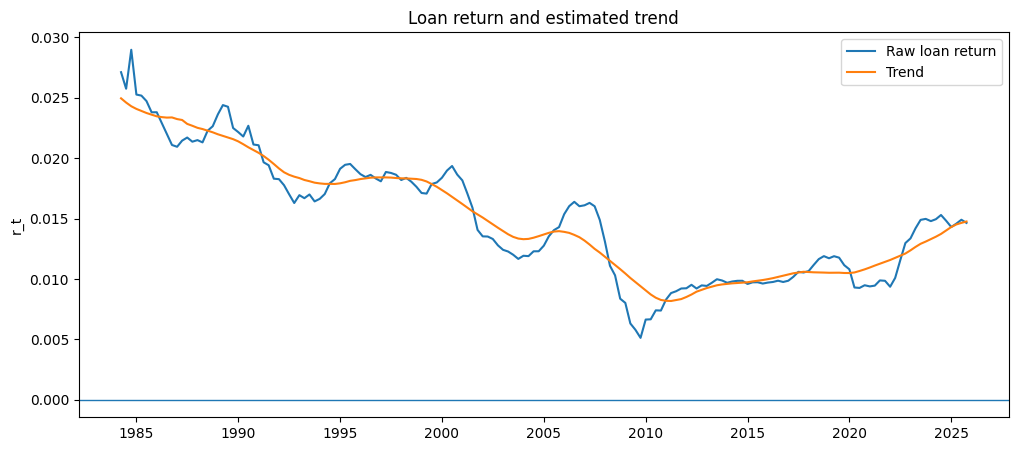

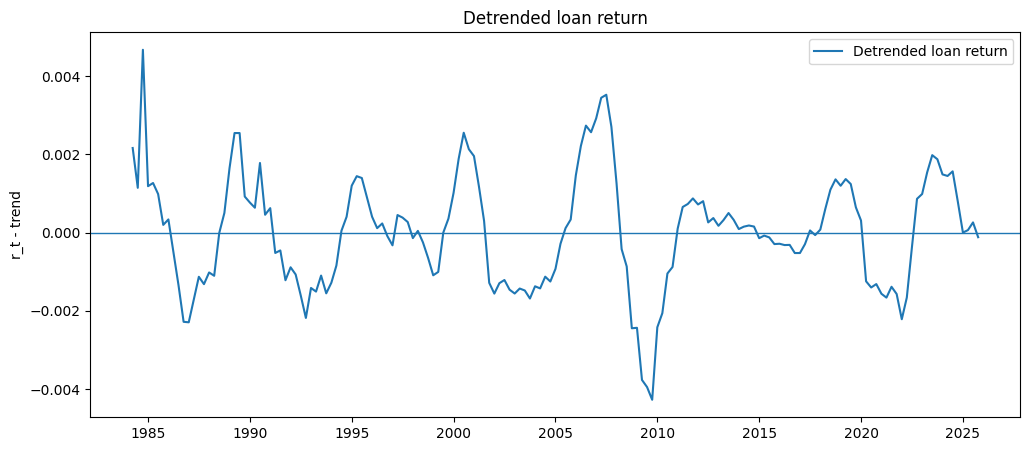

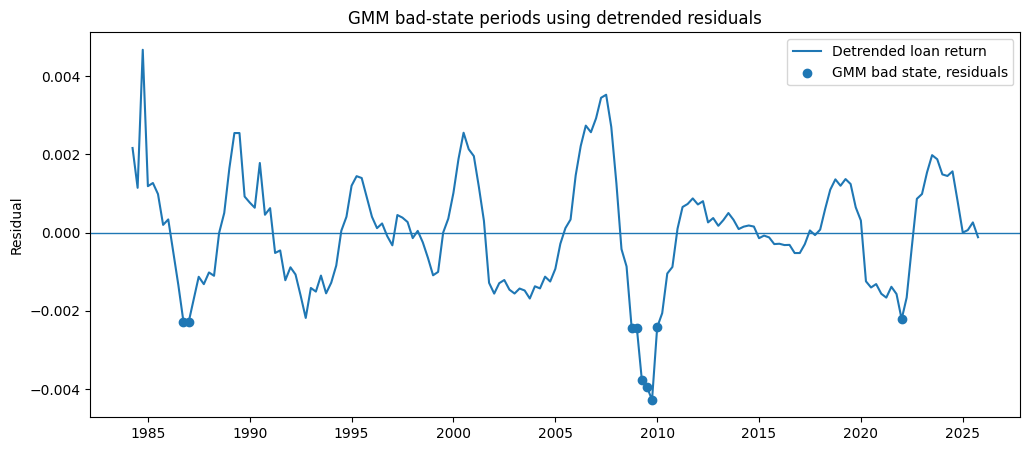

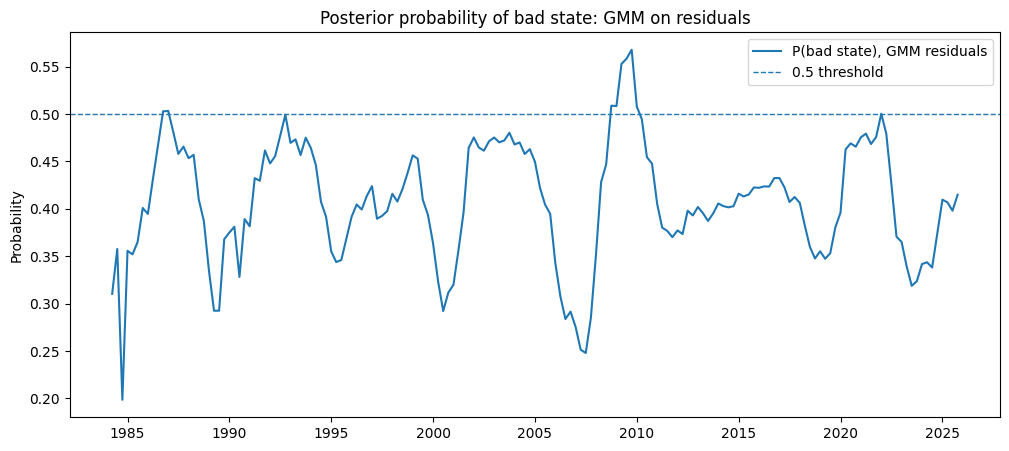

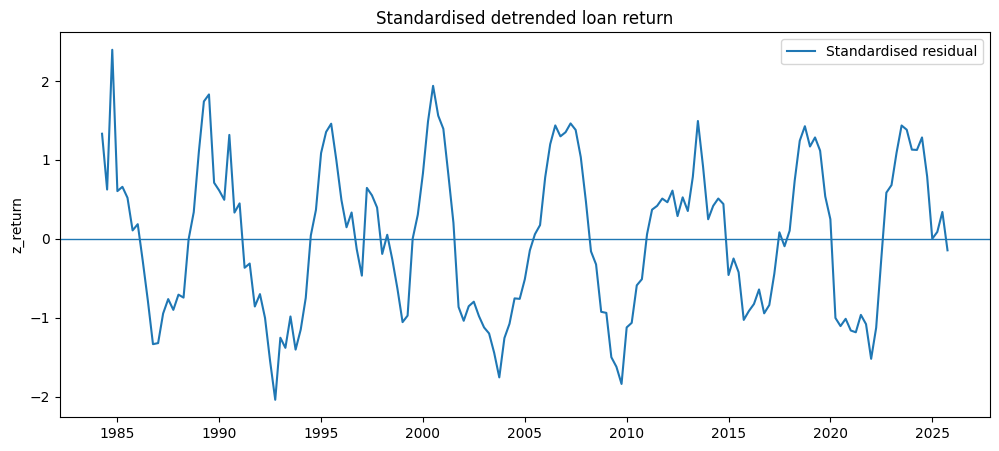

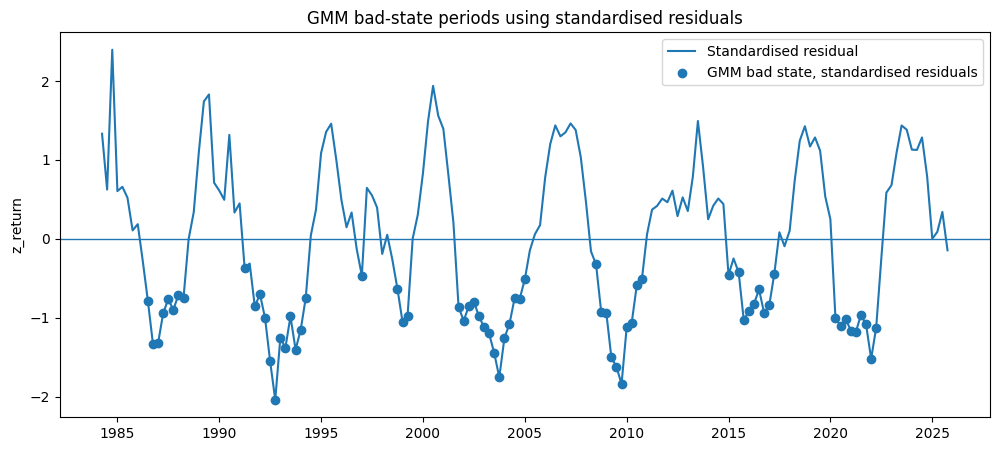

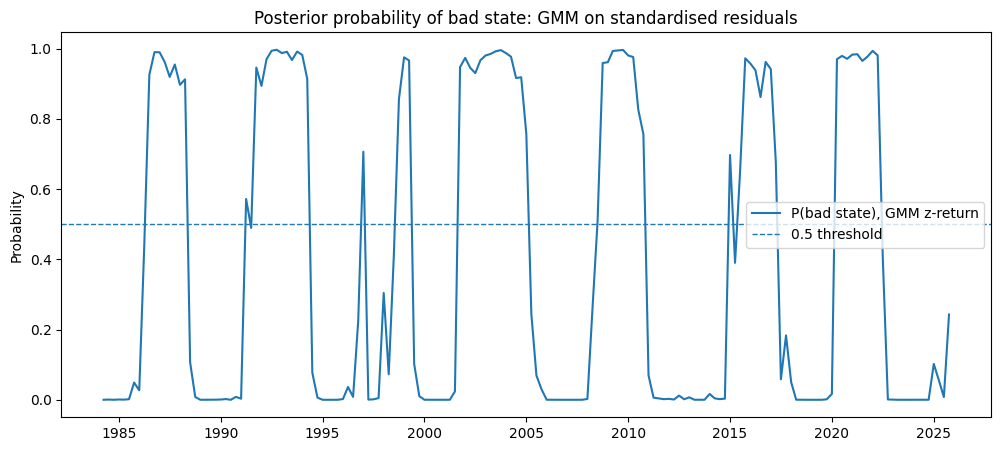

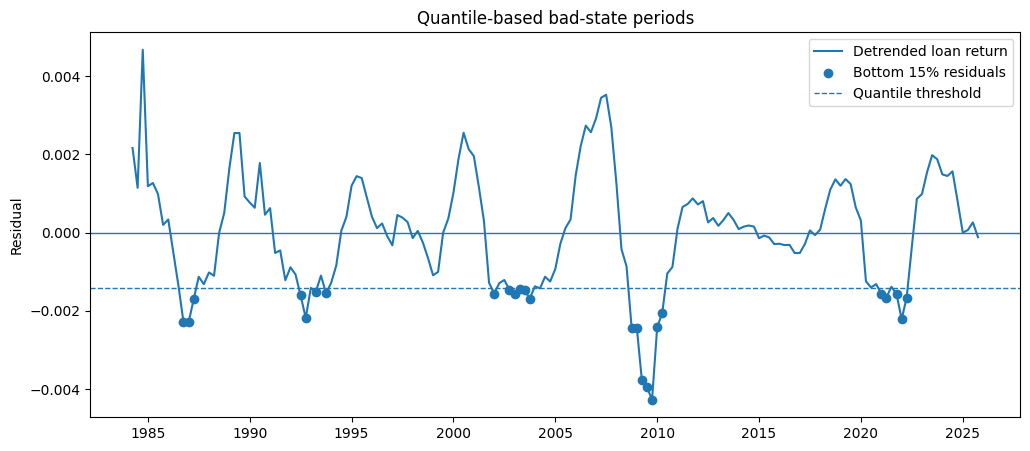

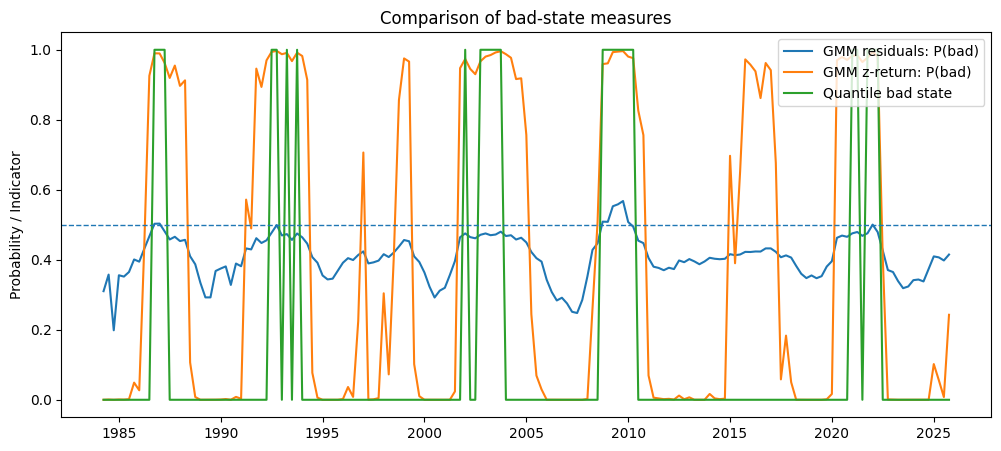

In [27]:
# -----------------------------
# Plot 1: Raw loan return and trend
# -----------------------------

plt.figure(figsize=(12, 5))
plt.plot(df.index, df["r_t"], label="Raw loan return")
plt.plot(df.index, df["trend"], label="Trend")
plt.axhline(0, linewidth=1)
plt.title("Loan return and estimated trend")
plt.ylabel("r_t")
plt.legend()
plt.show()


# -----------------------------
# Plot 2: Residuals after detrending
# -----------------------------

plt.figure(figsize=(12, 5))
plt.plot(df.index, df["resid"], label="Detrended loan return")
plt.axhline(0, linewidth=1)
plt.title("Detrended loan return")
plt.ylabel("r_t - trend")
plt.legend()
plt.show()


# -----------------------------
# Plot 3: GMM on residuals, hard bad-state labels
# -----------------------------

plt.figure(figsize=(12, 5))
plt.plot(df.index, df["resid"], label="Detrended loan return")
plt.scatter(
    df.loc[df["bad_gmm_resid"]].index,
    df.loc[df["bad_gmm_resid"], "resid"],
    label="GMM bad state, residuals",
    zorder=3
)
plt.axhline(0, linewidth=1)
plt.title("GMM bad-state periods using detrended residuals")
plt.ylabel("Residual")
plt.legend()
plt.show()


# -----------------------------
# Plot 4: GMM posterior probability on residuals
# -----------------------------

plt.figure(figsize=(12, 5))
plt.plot(df.index, df["p_bad_gmm_resid"], label="P(bad state), GMM residuals")
plt.axhline(0.5, linestyle="--", linewidth=1, label="0.5 threshold")
plt.title("Posterior probability of bad state: GMM on residuals")
plt.ylabel("Probability")
plt.legend()
plt.show()


# -----------------------------
# Plot 5: Standardised residuals
# -----------------------------

plt.figure(figsize=(12, 5))
plt.plot(df.index, df["z_return"], label="Standardised residual")
plt.axhline(0, linewidth=1)
plt.title("Standardised detrended loan return")
plt.ylabel("z_return")
plt.legend()
plt.show()


# -----------------------------
# Plot 6: GMM on standardised residuals, hard bad-state labels
# -----------------------------

plt.figure(figsize=(12, 5))
plt.plot(df.index, df["z_return"], label="Standardised residual")
plt.scatter(
    df.loc[df["bad_gmm_z"]].index,
    df.loc[df["bad_gmm_z"], "z_return"],
    label="GMM bad state, standardised residuals",
    zorder=3
)
plt.axhline(0, linewidth=1)
plt.title("GMM bad-state periods using standardised residuals")
plt.ylabel("z_return")
plt.legend()
plt.show()


# -----------------------------
# Plot 7: GMM posterior probability on standardised residuals
# -----------------------------

plt.figure(figsize=(12, 5))
plt.plot(df.index, df["p_bad_gmm_z"], label="P(bad state), GMM z-return")
plt.axhline(0.5, linestyle="--", linewidth=1, label="0.5 threshold")
plt.title("Posterior probability of bad state: GMM on standardised residuals")
plt.ylabel("Probability")
plt.legend()
plt.show()


# -----------------------------
# Plot 8: Quantile bad-state rule
# -----------------------------

plt.figure(figsize=(12, 5))
plt.plot(df.index, df["resid"], label="Detrended loan return")
plt.scatter(
    df.loc[df["bad_quantile"]].index,
    df.loc[df["bad_quantile"], "resid"],
    label=f"Bottom {int(tau * 100)}% residuals",
    zorder=3
)
plt.axhline(0, linewidth=1)
plt.axhline(threshold_resid, linestyle="--", linewidth=1, label="Quantile threshold")
plt.title("Quantile-based bad-state periods")
plt.ylabel("Residual")
plt.legend()
plt.show()


# -----------------------------
# Plot 9: Compare bad-state probabilities / indicators
# -----------------------------

plt.figure(figsize=(12, 5))
plt.plot(df.index, df["p_bad_gmm_resid"], label="GMM residuals: P(bad)")
plt.plot(df.index, df["p_bad_gmm_z"], label="GMM z-return: P(bad)")
plt.plot(df.index, df["bad_quantile"].astype(float), label="Quantile bad state")
plt.axhline(0.5, linestyle="--", linewidth=1)
plt.title("Comparison of bad-state measures")
plt.ylabel("Probability / Indicator")
plt.legend()
plt.show()

In [29]:
mu_g = est_z["mu_g"]
sigma_g = est_z["sigma_g"]
mu_b = est_z["mu_b"]
sigma_b = est_z["sigma_b"]
df["p_bad_target"] = df["p_bad_gmm_z"]
df["mu_g_r"] = df["trend"] + df["rolling_sigma"] * mu_g
df["sigma_g_r"] = df["rolling_sigma"] * sigma_g

df["mu_b_r"] = df["trend"] + df["rolling_sigma"] * mu_b
df["sigma_b_r"] = df["rolling_sigma"] * sigma_b
p = df["p_bad_target"]

df["expected_r"] = (
    (1 - p) * df["mu_g_r"]
    + p * df["mu_b_r"]
)

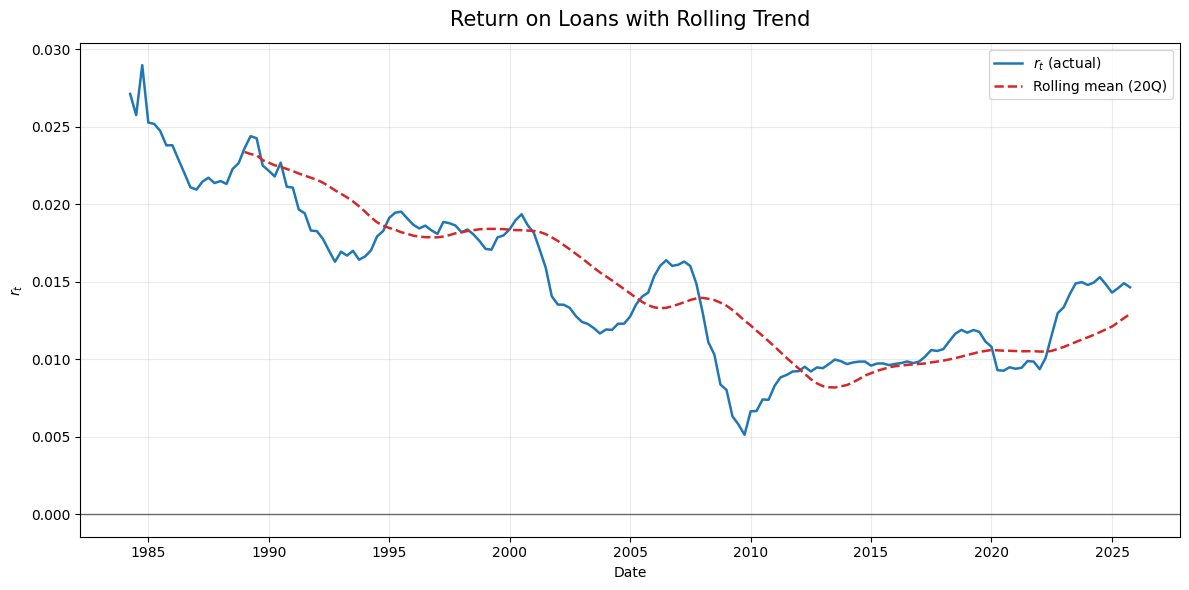

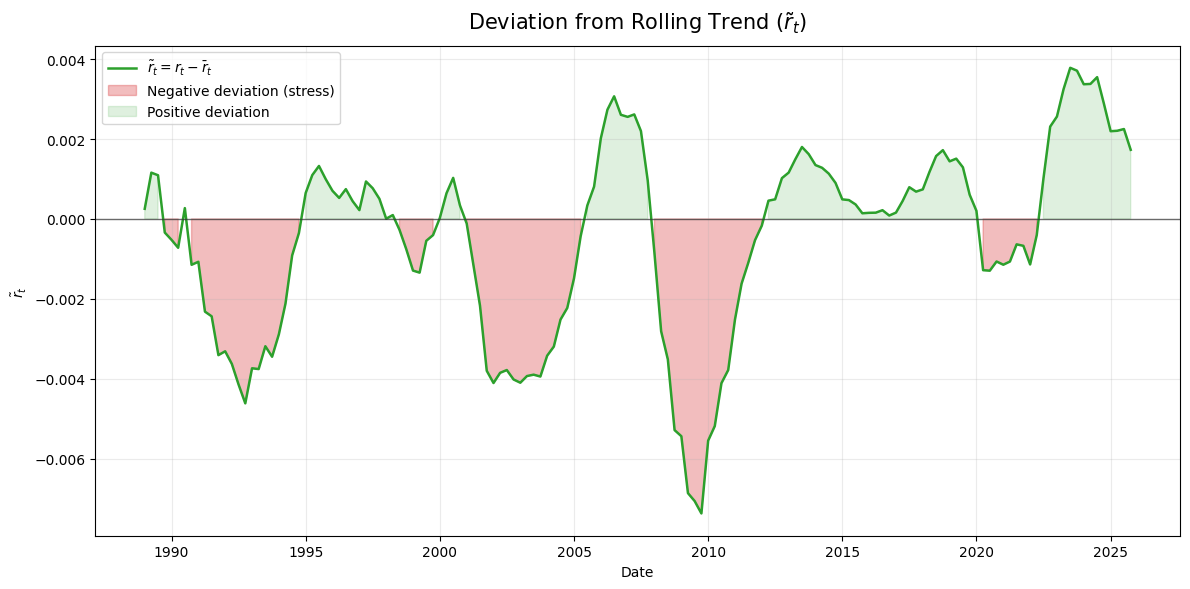

In [6]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- Compute rolling trend and deviation ---
window = 20  # 20 quarters ~ 5 years
fdic_data["r_t_trend"] = fdic_data["r_t"].rolling(window=window, center=False).mean()
fdic_data["r_t_dev"] = fdic_data["r_t"] - fdic_data["r_t_trend"]

# --- Plot 1: Return on Loans with Rolling Trend ---
fig1, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(fdic_data.index, fdic_data["r_t"], color="#1f77b4", linewidth=1.8, label="$r_t$ (actual)")
ax1.plot(fdic_data.index, fdic_data["r_t_trend"], color="#d62728", linewidth=1.8, 
         linestyle="--", label="Rolling mean (20Q)")
ax1.axhline(0, color="#333333", linewidth=1, alpha=0.7)

ax1.set_title("Return on Loans with Rolling Trend", fontsize=15, pad=12)
ax1.set_xlabel("Date")
ax1.set_ylabel("$r_t$")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.xaxis.set_major_locator(mdates.YearLocator(5))
ax1.legend()
ax1.grid(True, alpha=0.25)
fig1.tight_layout()

# --- Plot 2: Deviation from Rolling Trend ---
fig2, ax2 = plt.subplots(figsize=(12, 6))

ax2.plot(fdic_data.index, fdic_data["r_t_dev"], color="#2ca02c", linewidth=1.8, 
         label="$\\tilde{r}_t = r_t - \\bar{r}_t$")
ax2.axhline(0, color="#333333", linewidth=1, alpha=0.7)
ax2.fill_between(fdic_data.index, fdic_data["r_t_dev"], 0,
                 where=(fdic_data["r_t_dev"] < 0),
                 color="#d62728", alpha=0.3, label="Negative deviation (stress)")
ax2.fill_between(fdic_data.index, fdic_data["r_t_dev"], 0,
                 where=(fdic_data["r_t_dev"] >= 0),
                 color="#2ca02c", alpha=0.15, label="Positive deviation")

ax2.set_title("Deviation from Rolling Trend ($\\tilde{r}_t$)", fontsize=15, pad=12)
ax2.set_xlabel("Date")
ax2.set_ylabel("$\\tilde{r}_t$")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.xaxis.set_major_locator(mdates.YearLocator(5))
ax2.legend()
ax2.grid(True, alpha=0.25)
fig2.tight_layout()

plt.show()

In [7]:
fdic_data['r_t']

DATE
1984-01-01         NaN
1984-04-01    0.027111
1984-07-01    0.025742
1984-10-01    0.028966
1985-01-01    0.025260
                ...   
2024-10-01    0.014815
2025-01-01    0.014299
2025-04-01    0.014574
2025-07-01    0.014900
2025-10-01    0.014638
Name: r_t, Length: 168, dtype: float64

In [32]:
alpha_assumed = 0.9  # bank lends out 90% of capital
shortfall_threshold = np.percentile(fdic_data['r_t'][1:] , 25)
print(shortfall_threshold)
# Implied K_bar/K
K_bar_over_K = 1 + alpha_assumed * shortfall_threshold
print(f"K_bar/K needed: {K_bar_over_K:.4f}")
print(f"Implied regulatory minimum: {K_bar_over_K*100:.1f}% of capital")

0.01003116666041273
K_bar/K needed: 1.0090
Implied regulatory minimum: 100.9% of capital


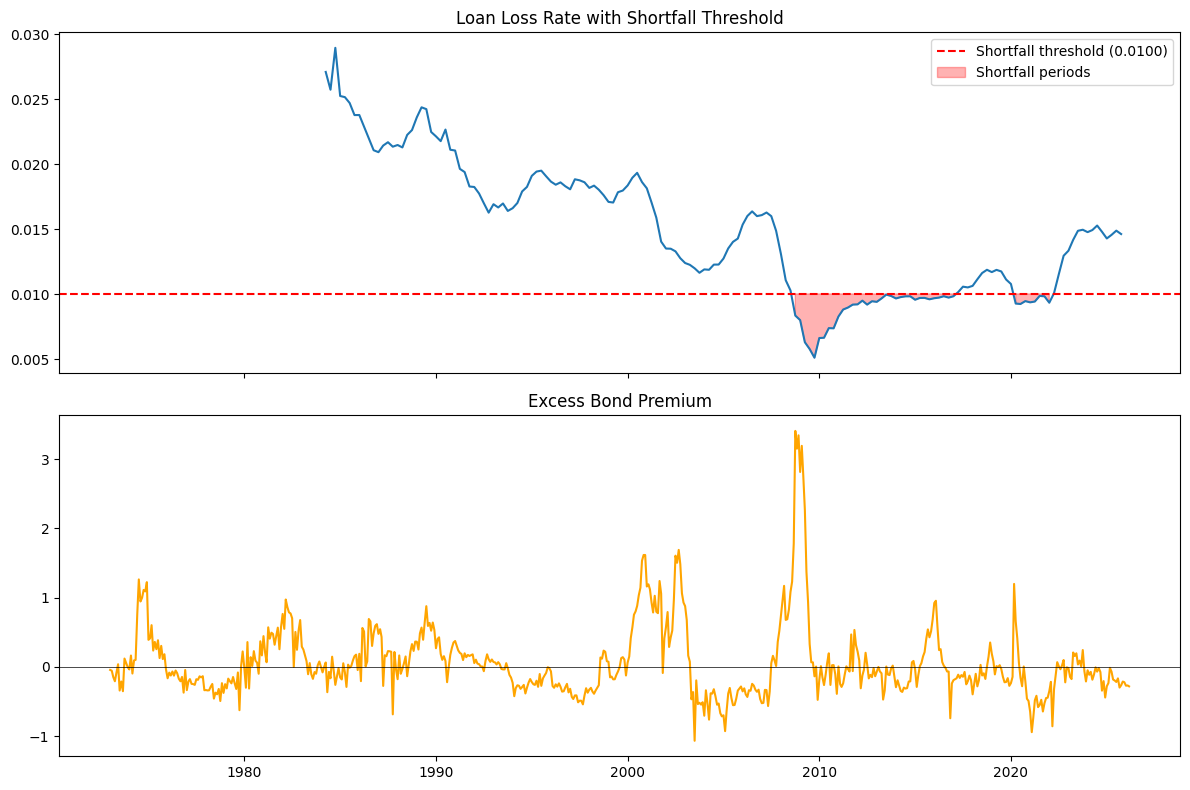

In [34]:
import matplotlib.pyplot as plt
ebp_data = pd.read_csv('raw/ebp.csv')
ebp_data = ebp_data.set_index('DATE')
ebp_data.index = pd.to_datetime(ebp_data.index)
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Top panel: loss rate
axes[0].plot(fdic_data['r_t'].index, fdic_data['r_t'].values)
axes[0].axhline(y=shortfall_threshold, color='red', 
                linestyle='--', label=f'Shortfall threshold ({shortfall_threshold:.4f})')
axes[0].fill_between(fdic_data['r_t'].index, fdic_data['r_t'].values, shortfall_threshold,
                     where=(fdic_data['r_t'].values < shortfall_threshold),
                     alpha=0.3, color='red', label='Shortfall periods')
axes[0].set_title('Loan Loss Rate with Shortfall Threshold')
axes[0].legend()

# Bottom panel: EBP for comparison
axes[1].plot(ebp_data.index, ebp_data.values, color='orange')
axes[1].set_title('Excess Bond Premium')
axes[1].axhline(y=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('loss_rate_vs_ebp.png')

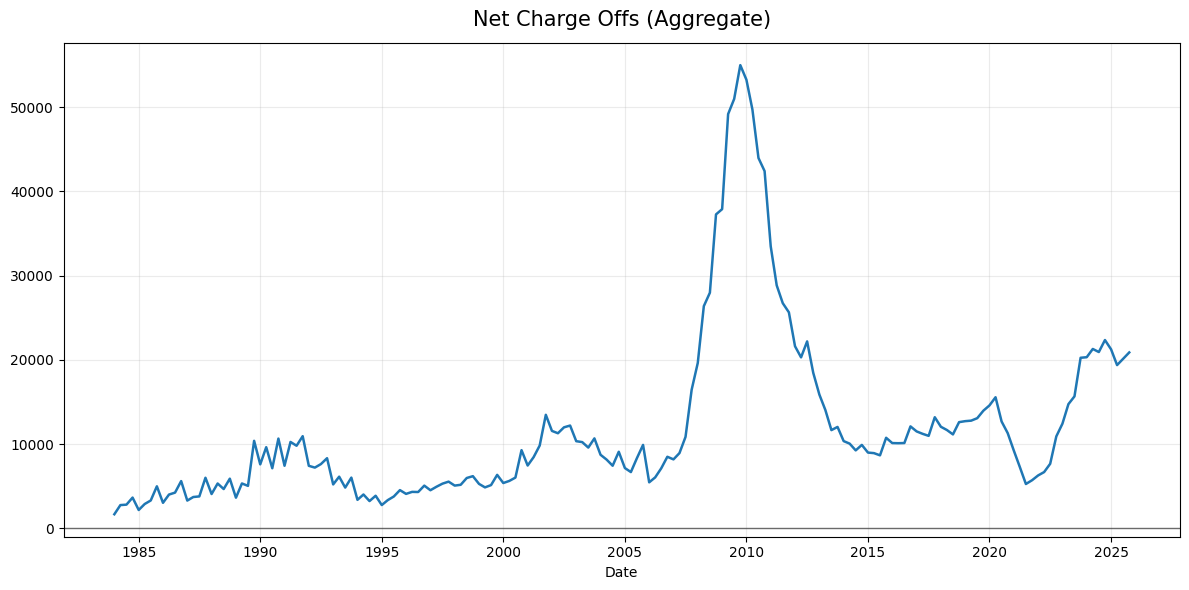

In [11]:

fig_rt, ax = plt.subplots(figsize=(12, 6))

ax.plot(fdic_data.index, fdic_data["net_chargeoffs"], color="#1f77b4", linewidth=1.8)
ax.axhline(0, color="#333333", linewidth=1, alpha=0.7)

ax.set_title("Net Charge Offs (Aggregate)", fontsize=15, pad=12)
ax.set_xlabel("Date")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))  
ax.xaxis.set_major_locator(mdates.YearLocator(5))         
ax.grid(True, alpha=0.25)

fig_rt.tight_layout()
plt.show()

In [18]:
charge_off_rate = fdic_data.net_chargeoffs / fdic_data.total_loans.shift(1)

In [19]:
fdic_data['charge_off_rate'] = charge_off_rate
fdic_data.charge_off_rate

DATE
1984-01-01         NaN
1984-04-01    0.001364
1984-07-01    0.001331
1984-10-01    0.001684
1985-01-01    0.000977
                ...   
2024-10-01    0.001772
2025-01-01    0.001671
2025-04-01    0.001516
2025-07-01    0.001543
2025-10-01    0.001582
Name: charge_off_rate, Length: 168, dtype: float64

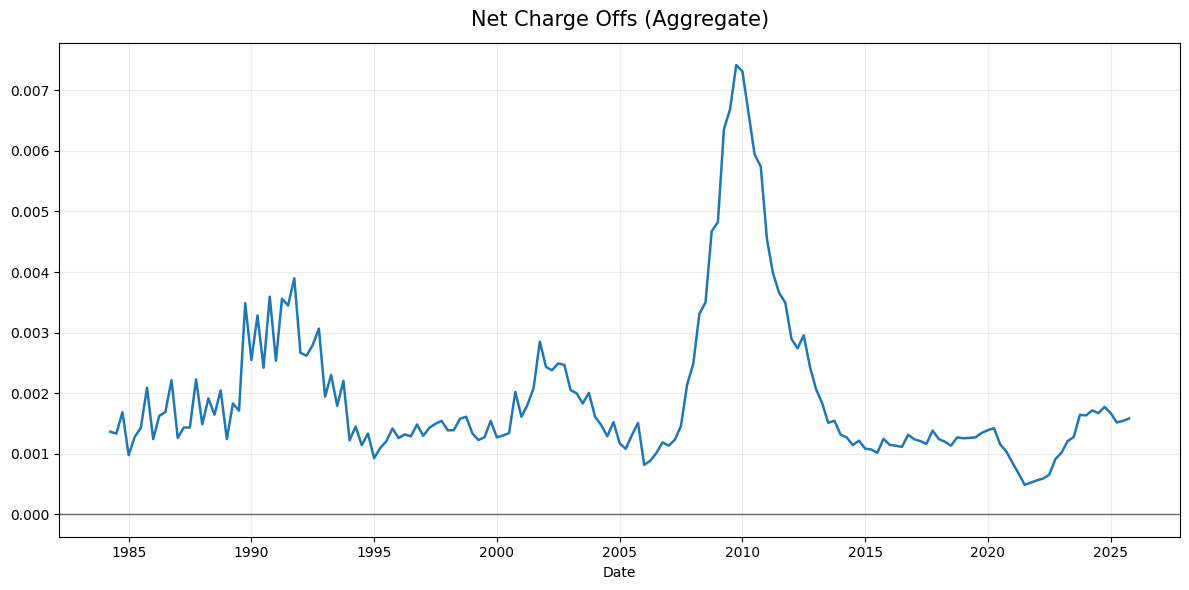

In [20]:

fig_rt, ax = plt.subplots(figsize=(12, 6))

ax.plot(fdic_data.index, fdic_data["charge_off_rate"], color="#1f77b4", linewidth=1.8)
ax.axhline(0, color="#333333", linewidth=1, alpha=0.7)

ax.set_title("Net Charge Offs (Aggregate)", fontsize=15, pad=12)
ax.set_xlabel("Date")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))  
ax.xaxis.set_major_locator(mdates.YearLocator(5))         
ax.grid(True, alpha=0.25)

fig_rt.tight_layout()
plt.show()

In [22]:
alpha_assumed = 0.9
r_t_loss = -(fdic_data.net_chargeoffs / fdic_data.total_loans.shift(1))

shortfall_threshold = np.percentile(r_t_loss.dropna(), 20)
K_bar_over_K = 1 + alpha_assumed * shortfall_threshold
print(f"r_t_loss range: {r_t_loss.min():.4f} to {r_t_loss.max():.4f}")
print(f"20th percentile: {shortfall_threshold:.4f}")
print(f"K_bar/K: {K_bar_over_K:.4f}")

r_t_loss range: -0.0074 to -0.0005
20th percentile: -0.0025
K_bar/K: 0.9978


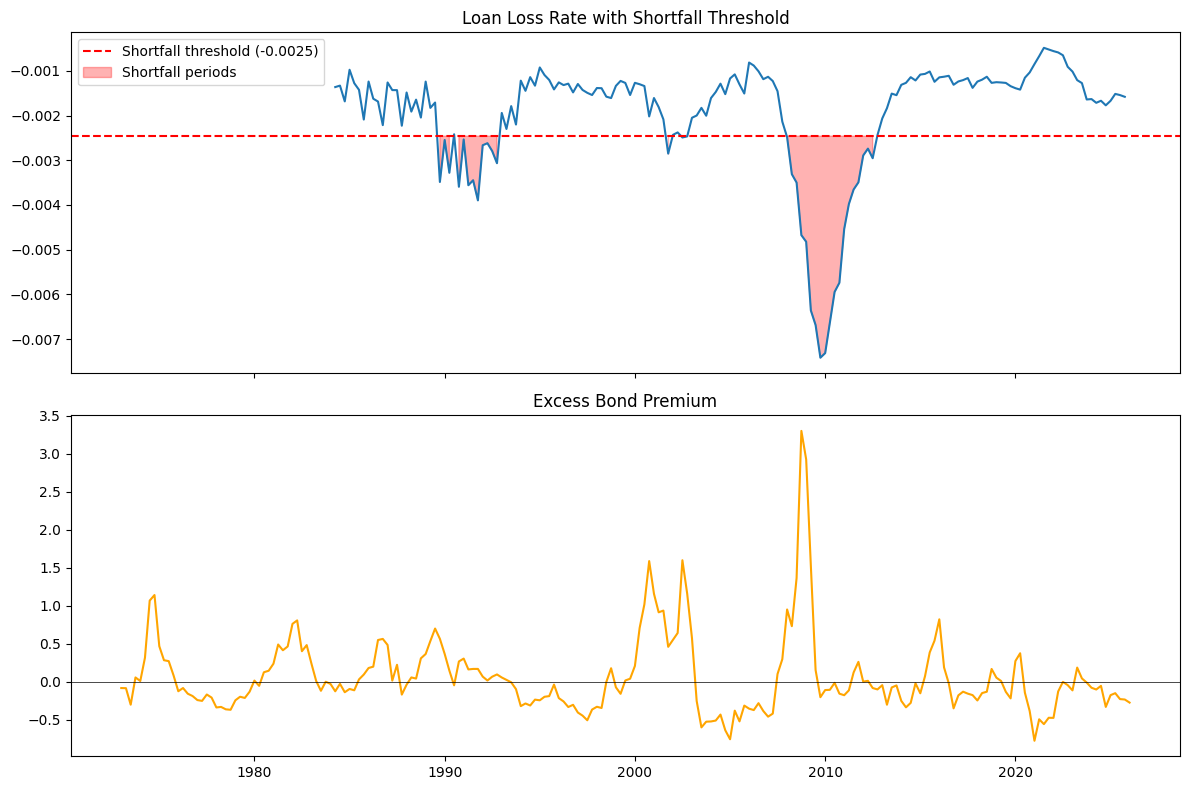

In [31]:
ebp_data = pd.read_csv('raw/ebp.csv')
ebp_data = ebp_data.set_index('DATE')
ebp_data.index = pd.to_datetime(ebp_data.index)
ebp_quarterly = ebp_data.resample('QS').mean()

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Top panel: loss rate
axes[0].plot(r_t_loss.index, r_t_loss.values)
axes[0].axhline(y=shortfall_threshold, color='red', 
                linestyle='--', label=f'Shortfall threshold ({shortfall_threshold:.4f})')
axes[0].fill_between(r_t_loss.index, r_t_loss.values, shortfall_threshold,
                     where=(r_t_loss.values < shortfall_threshold),
                     alpha=0.3, color='red', label='Shortfall periods')
axes[0].set_title('Loan Loss Rate with Shortfall Threshold')
axes[0].legend()

# Bottom panel: EBP for comparison
axes[1].plot(ebp_quarterly.index, ebp_quarterly.values, color='orange')
axes[1].set_title('Excess Bond Premium')
axes[1].axhline(y=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('loss_rate_vs_ebp.png')

In [30]:
ebp_quarterly

,EBP
DATE,
1973-01-01,-0.083142
1973-04-01,-0.084965
1973-07-01,-0.302438
1973-10-01,0.056336
1974-01-01,0.009406
...,...
2025-01-01,-0.176669
2025-04-01,-0.150769
2025-07-01,-0.228624
